In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

from src.compiler.qccd_WISE_ion_route import ionRoutingWISEArch
from src.simulator.qccd_circuit import QCCDCircuit
from src.utils.qccd_arch import QCCDWiseArch
from src.compiler.qccd_parallelisation import paralleliseOperationsWithBarriers
import time


In [4]:
!python -m pip install pandas

3888.18s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 6.4 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pandas]2m2/3 [pandas]


In [2]:
def run_single_config(
    lookahead: int,
    subgrid_width: int,
    subgrid_height: int,
    subgrid_increment: int,
    *,
    d: int = 4,                 # code distance
    m_traps: int = 6,           # number of trap columns in the WISE arch
    n_traps: int = 6,           # number of trap rows in the WISE arch
    trap_capacity: int = 2,
    barrier_threshold: float = np.inf,
    go_back_threshold: float = 0.0,
) -> tuple[float, float, float]:
    """
    Run the WISE routing for a single (lookahead, subgridsize, increment) config.

    Parameters
    ----------
    lookahead : int
        Number of two-qubit rounds to include in the local optimisation window.
    subgrid_width : int
        Initial subgrid width (in columns of the m*k ion grid).
    subgrid_height : int
        Initial subgrid height (in rows).
    subgrid_increment : int
        How many rows/cols to grow the subgrid by at each expansion.
    d : int, optional
        Surface code distance (used in QCCDCircuit.generated).
    m_traps : int, optional
        Number of trap columns in the WISE architecture (QCCDWiseArch.m).
    n_traps : int, optional
        Number of trap rows in the WISE architecture (QCCDWiseArch.n).
    trap_capacity : int, optional
        Ions per trap (QCCDWiseArch.k).
    barrier_threshold, go_back_threshold : float, optional
        As in your existing script.

    Returns
    -------
    (exec_time, comp_time) : (float, float)
        exec_time : circuit execution time (max parallel timestep).
        comp_time : wall-clock time for compilation for this config.
    """
    t0 = time.perf_counter()
    try:
        # Generate circuit with the chosen code distance
        circuit = QCCDCircuit.generated(
            "surface_code:rotated_memory_z",
            rounds=1,
            distance=d,
        )

        # Architecture with parameterised rows/cols
        wiseArch = QCCDWiseArch(
            m=m_traps,
            n=n_traps,
            k=trap_capacity,
        )

        arch, (instructions, opBarriers) = circuit.processCircuitWiseArch(
            wiseArch=wiseArch
        )
        arch.refreshGraph()

        # Barrier logic as in your script
        opBarriers = opBarriers if trap_capacity <= barrier_threshold else []

        subgridsize = (subgrid_width, subgrid_height, subgrid_increment)

        # Core routing
        allOps, barriers = ionRoutingWISEArch(
            arch,
            wiseArch,
            instructions,
            lookahead=lookahead,
            subgridsize=subgridsize,
        )

        # Parallel schedule
        parallelOpsMap = paralleliseOperationsWithBarriers(allOps, barriers)
        if len(parallelOpsMap) == 0:
            exec_time = 0.0
        else:
            exec_time = float(max(parallelOpsMap.keys()))

        logicalerror = circuit.simulate(allOps, isWISEArch=True)[0]

        t1 = time.perf_counter()
        comp_time = t1 - t0

        return exec_time, comp_time, logicalerror

    except Exception as e:
        t1 = time.perf_counter()
        comp_time = t1 - t0
        print(
            f"[WARN] Failed for lookahead={lookahead}, "
            f"subgrid=({subgrid_width},{subgrid_height},{subgrid_increment}), "
            f"d={d}, m_traps={m_traps}, n_traps={n_traps}: {e}"
        )
        # exec_time NaN, but keep compilation time to see failures too
        return np.nan, comp_time, np.nan


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product

from src.compiler.qccd_WISE_ion_route import ionRoutingWISEArch
from src.simulator.qccd_circuit import QCCDCircuit
from src.utils.qccd_arch import QCCDWiseArch
from src.compiler.qccd_parallelisation import paralleliseOperationsWithBarriers
import time


d=3
trapCapacity=2
la=4
nqubitsNeeded = 2 * d**2 - 1
nrowsNeeded = int(np.ceil(np.sqrt(nqubitsNeeded)))
ncolsNeeded = int(np.ceil(nrowsNeeded/trapCapacity))
subgridsize=(ncolsNeeded*trapCapacity,nrowsNeeded,1)

w,h,inc = subgridsize


print(f"Running config: lookahead={la}, subgrid=({w},{h},{inc})")
exec_time, comp_time, le = run_single_config(
    lookahead=la,
    subgrid_width=w,
    subgrid_height=h,
    subgrid_increment=inc,
    d=d,
    m_traps=ncolsNeeded,
    n_traps=nrowsNeeded,
    trap_capacity=trapCapacity
)

print(exec_time, comp_time, le)




Running config: lookahead=4, subgrid=(6,5,1)
[WISE] ions_all=30, active_ions=17, spectator_ions=13
[WISE] starting binary search for D in [0, 5]
[WISE] build_structural_cnf(D=2/SAT): D_bound=2, use_wcnf=False, boundary_soft=False, n=5, m=6, R=4
        round 0: |Res_r|=0, |Free_r|=30, |P[r]|=6, |BT[r]|=0
        round 1: |Res_r|=0, |Free_r|=30, |P[r]|=7, |BT[r]|=0
        round 2: |Res_r|=0, |Free_r|=30, |P[r]|=5, |BT[r]|=0
        round 3: |Res_r|=0, |Free_r|=30, |P[r]|=6, |BT[r]|=0
[WISE] SAT worker starting (timeout=360.0s) for CNF: clauses=71892
[WISE] SAT worker finished in 0.078s, SAT=True
[WISE]  test D=2: status=ok, SAT=True, vars=20310, clauses=71892, time=0.373s
[WISE] build_structural_cnf(D=0/SAT): D_bound=0, use_wcnf=False, boundary_soft=False, n=5, m=6, R=4
        round 0: |Res_r|=0, |Free_r|=30, |P[r]|=6, |BT[r]|=0
        round 1: |Res_r|=0, |Free_r|=30, |P[r]|=7, |BT[r]|=0
        round 2: |Res_r|=0, |Free_r|=30, |P[r]|=5, |BT[r]|=0
        round 3: |Res_r|=0, |Free_r|

In [ ]:
import math
import time
import numpy as np
import pandas as pd

# ----------------------------
# knobs to tweak quickly
# ----------------------------
k_values = [2,3,4]
lookahead_values      = [1, 4]
d_values              = [2, 4,6,8,10]
subgrid_area_values   = [4,8, 16, 64, 196, 400, 900, 1600]   # requested areas (w*h)

RESULTS_CSV = "wise_scaling_results_area_diffk.csv"
VERBOSE = True
DEFAULT_INC = 1  # legacy arg for your runner

def _fullgrid_dims(d: int, k: int):
    nqubits_needed = 2 * d**2 - 1
    nrows_needed   = int(math.ceil(math.sqrt(nqubits_needed)))   # rows
    ncols_needed   = int(math.ceil(nrows_needed / k))            # traps per row
    eff_w = ncols_needed * k   # columns
    eff_h = nrows_needed       # rows
    return eff_w, eff_h

def _pick_wh_from_area(area: int, W_full: int, H_full: int):
    area = int(max(1, area))
    ratio = W_full / H_full if H_full > 0 else 1.0
    w = int(max(1, round(math.sqrt(area * ratio))))
    h = int(max(1, area // max(1, w)))
    while (w * (h + 1)) <= area and (h + 1) <= H_full:
        h += 1
    w = min(max(1, w), W_full)
    h = min(max(1, h), H_full)
    while w * h > area and h > 1:
        h -= 1
    return w, h

rows = []
t0_all = time.time()

print("Experiment settings:")
print("  k:", k_values)
print("  lookahead:", lookahead_values)
print("  d values:", d_values)
print("  subgrid areas:", subgrid_area_values)
for k in k_values:
    for d in d_values:
        W_full, H_full = _fullgrid_dims(d, k)
        full_area = W_full * H_full

        # keep only requested areas <= full_area, then append the exact full_area
        areas = sorted(a for a in set(subgrid_area_values) if a <= full_area)
        if areas[-1] != full_area:
            areas.append(full_area)

        if VERBOSE:
            print(f"\n[d={d}, k={k}] full-grid = (W={W_full}, H={H_full}), full-area = {full_area}")
            print(" testing areas (capped):", areas)

        area_to_wh = {A: _pick_wh_from_area(A, W_full, H_full) for A in areas}
        if VERBOSE:
            for A, (w,h) in area_to_wh.items():
                eff_area = min(w, W_full) * min(h, H_full)
                tag = " (full-grid)" if (w >= W_full and h >= H_full) else ""
                print(f"  A={A:>6d} -> (w,h)=({w:>3d},{h:>3d}), eff_area={eff_area}{tag}")

        for la in lookahead_values:
            for A in areas:
                w, h = area_to_wh[A]
                if VERBOSE:
                    print(f"Running d={d}, k={k}, la={la}, area={A} -> subgrid=({w},{h})")

                try:
                    exec_time, comp_time,logicalrate = run_single_config(
                        lookahead=la,
                        subgrid_width=w,
                        subgrid_height=h,
                        subgrid_increment=DEFAULT_INC,   # ignored by your code now
                        d=d,
                        m_traps=int(math.ceil(H_full / k)),
                        n_traps=H_full,
                        trap_capacity=k,
                    )
                    err = None
                except Exception as e:
                    exec_time, comp_time, logicalrate, err = (np.nan, np.nan,np.nan, repr(e))
                    print(f"  -> ERROR: {err}")

                rows.append({
                    "d": d,
                    "k": k,
                    "lookahead": la,
                    "subgrid_area_req": int(A),
                    "subgrid_width": int(w),
                    "subgrid_height": int(h),
                    "eff_width": int(min(w, W_full)),
                    "eff_height": int(min(h, H_full)),
                    "eff_area": int(min(w, W_full) * min(h, H_full)),
                    "is_fullgrid": int(w >= W_full and h >= H_full),
                    "exec_time": exec_time,
                    "comp_time": comp_time,
                    "error": err,
                    "logical_rate": logicalrate
                })

df2 = pd.DataFrame(rows)
df2.to_csv(RESULTS_CSV, index=False)
t1_all = time.time()
print(f"\nDone. Wrote {len(df)} rows to {RESULTS_CSV} in {t1_all - t0_all:.1f}s")
df2.head()

Experiment settings:
  k: [6, 2]
  lookahead: [1, 4]
  d values: [2, 4, 6, 8, 10]
  subgrid areas: [4, 8, 16, 64, 196, 400, 900, 1600]

[d=2, k=6] full-grid = (W=6, H=3), full-area = 18
 testing areas (capped): [4, 8, 16, 18]
  A=     4 -> (w,h)=(  3,  1), eff_area=3
  A=     8 -> (w,h)=(  4,  2), eff_area=8
  A=    16 -> (w,h)=(  6,  2), eff_area=12
  A=    18 -> (w,h)=(  6,  3), eff_area=18 (full-grid)
Running d=2, k=6, la=1, area=4 -> subgrid=(3,1)
[WISE] ions_all=3, active_ions=7, spectator_ions=3
[WISE] starting binary search for D in [0, 2]
[WISE] build_structural_cnf(D=1/SAT): D_bound=1, use_wcnf=False, boundary_soft=False, n=1, m=3, R=1
        round 0: |Res_r|=0, |Free_r|=3, |P[r]|=0, |BT[r]|=0
[WISE] SAT worker starting (timeout=360.0s) for CNF: clauses=251
[WISE] SAT worker finished in 0.000s, SAT=True
[WISE]  test D=1: status=ok, SAT=True, vars=128, clauses=251, time=0.508s
[WISE] build_structural_cnf(D=0/SAT): D_bound=0, use_wcnf=False, boundary_soft=False, n=1, m=3, R=1
 

In [7]:
print(len(rows))

94


In [8]:
df2 = pd.DataFrame(rows)
df2.to_csv(RESULTS_CSV, index=False)
t1_all = time.time()
print(f"\nDone. Wrote {len(rows)} rows to {RESULTS_CSV} in {t1_all - t0_all:.1f}s")
df2.head()


Done. Wrote 94 rows to wise_scaling_results_area_diffk.csv in 43961.5s


,d,k,lookahead,subgrid_area_req,subgrid_width,subgrid_height,eff_width,eff_height,eff_area,is_fullgrid,exec_time,comp_time,error,logical_rate
0,2,6,1,4,3,1,3,1,3,0,0.038736,27.259670,None,0.12124
1,2,6,1,8,4,2,4,2,8,0,0.038736,17.546593,None,0.11979
2,2,6,1,16,6,2,6,2,12,0,0.039968,12.736853,None,0.12178
3,2,6,1,18,6,3,6,3,18,1,0.039472,4.991437,None,0.12263
4,2,6,4,4,3,1,3,1,3,0,0.043629,26.514548,None,0.12071


In [ ]:
import itertools as it
import math
import os
import time
import numpy as np
import pandas as pd

# -----------------------------
# knobs you can tweak quickly
# -----------------------------
k = 2
lookahead_values         = [1, 2, 3, 4]
subgrid_width_values     = [2, 4, 8, 16, 32]   # in columns (in m*k grid space)
subgrid_height_values    = [2, 4, 8, 16, 32]  # in rows
subgrid_increment_values = [1]

d_values = [2, 3, 4, 5, 6, 7, 8]

RESULTS_CSV = "wise_scaling_results_streamlined.csv"
CHECKPOINT_EVERY = 10   # save every N runs
MAX_AREA_SAMPLES = 8    # per d: keep at most this many distinct (w,h) areas (set None to keep all)
AREA_BINNING = 8        # when subsampling, number of bins across area
VERBOSE = True

def _fullgrid_dims(d: int, k: int):
    """
    For a given code distance d and trap capacity k, compute the
    effective full-grid (width,height) (in same units as your subgrid inputs).
    """
    nqubitsNeeded = 2 * d**2 - 1
    nrowsNeeded   = int(math.ceil(math.sqrt(nqubitsNeeded)))   # rows
    ncolsNeeded   = int(math.ceil(nrowsNeeded / k))            # traps per row
    eff_w = ncolsNeeded * k
    eff_h = nrowsNeeded
    return eff_w, eff_h

def _make_unique_wh_for_d(d, k, w_list, h_list):
    """
    Clip (w,h) to full-grid, always include the true full-grid once,
    and dedupe.
    Optionally subsample by area (to keep run-time down).
    """
    W_full, H_full = _fullgrid_dims(d, k)

    # Clip and dedupe
    pairs = set()
    for w, h in it.product(w_list, h_list):
        ww = min(int(w), W_full)
        hh = min(int(h), H_full)
        pairs.add((ww, hh))
    pairs.add((W_full, H_full))  # guarantee full-grid once

    pairs = sorted(pairs, key=lambda t: (t[0]*t[1], t[0], t[1]))

    if MAX_AREA_SAMPLES is None or len(pairs) <= MAX_AREA_SAMPLES:
        return pairs

    # Subsample by area quantiles to keep signal while reducing runs
    areas = np.array([w*h for (w,h) in pairs], dtype=float)
    bins = np.linspace(areas.min(), areas.max(), AREA_BINNING+1)
    # assign each pair to a bin
    bin_idx = np.digitize(areas, bins[1:-1], right=False)
    # pick ~uniformly across bins up to MAX_AREA_SAMPLES
    chosen = []
    # always keep full-grid
    chosen.append((W_full, H_full))
    # Fill remaining slots by picking one representative per bin (closest to bin center)
    remaining = MAX_AREA_SAMPLES - 1
    if remaining > 0:
        # compute a target area per bin
        centers = 0.5 * (bins[:-1] + bins[1:])
        # for each bin, pick candidate closest to center
        for b in range(AREA_BINNING):
            idxs = [i for i, bi in enumerate(bin_idx) if bi == b]
            if not idxs:
                continue
            if remaining == 0:
                break
            target = centers[b]
            best_i = min(idxs, key=lambda i: abs(areas[i] - target))
            cand = pairs[best_i]
            if cand not in chosen:
                chosen.append(cand)
                remaining -= 1

    # If still short, backfill smallest areas not chosen
    if remaining > 0:
        for p in pairs:
            if p not in chosen:
                chosen.append(p)
                remaining -= 1
                if remaining == 0:
                    break

    # Stable order by area
    chosen = sorted(chosen, key=lambda t: (t[0]*t[1], t[0], t[1]))
    return chosen

# Optionally resume
if os.path.exists(RESULTS_CSV):
    df_prev = pd.read_csv(RESULTS_CSV)
    have = {
        (int(r.d), int(r.k), int(r.lookahead),
         int(r.subgrid_width), int(r.subgrid_height), int(r.subgrid_increment))
        for _, r in df_prev.iterrows()
    }
    results = df_prev.to_dict("records")
    if VERBOSE:
        print(f"[resume] loaded {len(results)} existing rows from {RESULTS_CSV}")
else:
    have = set()
    results = []

run_counter = 0
t0_all = time.time()

print("Parameter grid sizes:")
print("  lookahead:", lookahead_values)
print("  width    :", subgrid_width_values)
print("  height   :", subgrid_height_values)
print("  increment:", subgrid_increment_values)
print("Streamlining: dedup + clip to full-grid per (d,k), subsample areas =", MAX_AREA_SAMPLES)

for d in d_values:
    W_full, H_full = _fullgrid_dims(d, k)
    WH_list = _make_unique_wh_for_d(d, k, subgrid_width_values, subgrid_height_values)

    if VERBOSE:
        print(f"\n[d={d}, k={k}] full-grid=({W_full},{H_full}); "
              f"evaluating {len(WH_list)} (w,h) settings after streamlining")

    for la, (w, h), inc in it.product(lookahead_values, WH_list, subgrid_increment_values):
        key = (int(d), int(k), int(la), int(w), int(h), int(inc))
        if key in have:
            continue

        print(f"Running d={d}, k={k}, la={la}, subgrid=({w},{h},{inc})")
        try:
            exec_time, comp_time = run_single_config(
                lookahead=la,
                subgrid_width=w,
                subgrid_height=h,
                subgrid_increment=inc,
                d=d,
                m_traps=int(math.ceil(H_full / k)),  # == ncolsNeeded for this d,k
                n_traps=H_full,                      # == nrowsNeeded
                trap_capacity=k,
            )
            err = None
        except Exception as e:
            exec_time, comp_time, err = (np.nan, np.nan, repr(e))
            print(f"  -> ERROR: {err}")

        results.append({
            "d": d,
            "k": k,
            "lookahead": la,
            "subgrid_width": w,
            "subgrid_height": h,
            "subgrid_increment": inc,
            "exec_time": exec_time,
            "comp_time": comp_time,
            "error": err,
            "is_fullgrid": int(w >= W_full and h >= H_full),
            "eff_width": min(w, W_full),
            "eff_height": min(h, H_full),
            "eff_area": min(w, W_full) * min(h, H_full),
        })
        have.add(key)
        run_counter += 1

        if run_counter % CHECKPOINT_EVERY == 0:
            pd.DataFrame(results).to_csv(RESULTS_CSV, index=False)
            print(f"[checkpoint] wrote {len(results)} rows to {RESULTS_CSV}")

# final write
pd.DataFrame(results).to_csv(RESULTS_CSV, index=False)
t1_all = time.time()
print(f"\nDone. Wrote {len(results)} rows to {RESULTS_CSV} in {t1_all - t0_all:.1f}s")

In [5]:
with open('saved_wise_Data_SAT_solver1.txt', 'w') as f:
    f.write(str(results))

In [10]:

data=[]
for d in results.keys():
    for k in results[d].keys():
        entries = results[d][k]
        for e in entries:
            e["d"]=d
            e["k"]=k
            data.append(e)

df = pd.DataFrame(data)
df.to_csv("wise_scaling_results.csv", index=False)

In [ ]:
df

,lookahead,subgrid_width,subgrid_height,subgrid_increment,exec_time,comp_time,d,k
0,1,2,2,1,NaN,5.845287,2,2
1,1,2,4,1,NaN,5.602336,2,2
2,1,2,8,1,NaN,4.600988,2,2
3,1,2,16,1,NaN,4.437032,2,2
4,1,2,32,1,NaN,4.761161,2,2
...,...,...,...,...,...,...,...,...
1365,3,16,2,1,0.068530,693.650395,6,4
1366,3,16,4,1,0.060002,1206.656684,6,4
1367,3,16,8,1,0.053749,422.400631,6,4
1368,3,16,16,1,0.061306,920.846576,6,4


OSError: [Errno 30] Read-only file system: '/mnt'

In [1]:

d=6
trapCapacity=2
la=4
nqubitsNeeded = 2 * d**2 - 1
nrowsNeeded = int(np.ceil(np.sqrt(nqubitsNeeded)))
ncolsNeeded = int(np.ceil(nrowsNeeded/trapCapacity))
subgridsize=(ncolsNeeded*trapCapacity,nrowsNeeded,1)

w,h,inc = subgridsize


print(f"Running config: lookahead={la}, subgrid=({w},{h},{inc})")
exec_time, comp_time = run_single_config(
    lookahead=la,
    subgrid_width=w,
    subgrid_height=h,
    subgrid_increment=inc,
    d=d,
    m_traps=ncolsNeeded,
    n_traps=nrowsNeeded,
    trap_capacity=trapCapacity
)

print(exec_time, comp_time)




NameError: name 'np' is not defined

In [ ]:
d=2 : 4,4,5,3

d=3 : 8,8,6,6

d=4 : 9,9,9,6

d=5 : 9,10,10,8

d=6 : 16,13,14,11

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# use the new results as the main df
df = df2.copy()
df.head()

,d,k,lookahead,subgrid_area_req,subgrid_width,subgrid_height,eff_width,eff_height,eff_area,is_fullgrid,exec_time,comp_time,error,logical_rate
0,2,6,1,4,3,1,3,1,3,0,0.038736,27.259670,None,0.12124
1,2,6,1,8,4,2,4,2,8,0,0.038736,17.546593,None,0.11979
2,2,6,1,16,6,2,6,2,12,0,0.039968,12.736853,None,0.12178
3,2,6,1,18,6,3,6,3,18,1,0.039472,4.991437,None,0.12263
4,2,6,4,4,3,1,3,1,3,0,0.043629,26.514548,None,0.12071


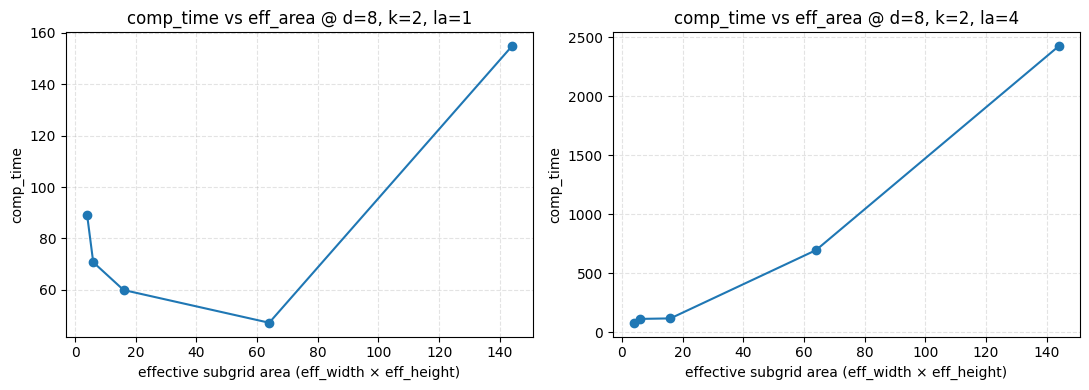

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# small aggregation helper (median + spread) to reduce noise
def agg_median_spread(frame, y="comp_time"):
    g = (
        frame
        .groupby(["d", "k", "lookahead", "eff_area"], as_index=False)[y]
        .agg(
            median="median",
            p25=lambda s: np.nanpercentile(s, 25),
            p75=lambda s: np.nanpercentile(s, 75),
        )
    )
    return g

# choose a default slice you can change quickly
D_FIXED  = 8        # change as you want
K_FIXED  = 2        # change as you want
Y_METRIC = "comp_time"   # "comp_time", "exec_time", or "logical_rate"

sub = df[(df["d"] == D_FIXED) & (df["k"] == K_FIXED) & df[Y_METRIC].notna()]
if sub.empty:
    print("no data for this slice")
else:
    g = agg_median_spread(sub, y=Y_METRIC)

    las = sorted(g["lookahead"].unique())
    ncol = min(3, len(las))
    nrow = int(np.ceil(len(las) / ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.5 * ncol, 4 * nrow), squeeze=False)

    for ax, la in zip(axes.flat, las):
        gg = g[g["lookahead"] == la].sort_values("eff_area")
        ax.plot(gg["eff_area"], gg["median"], marker="o", label=f"la={la}")
        ax.fill_between(gg["eff_area"], gg["p25"], gg["p75"], alpha=0.2)
        ax.set_title(f"{Y_METRIC} vs eff_area @ d={D_FIXED}, k={K_FIXED}, la={la}")
        ax.set_xlabel("effective subgrid area (eff_width × eff_height)")
        ax.set_ylabel(Y_METRIC)
        ax.grid(True, linestyle="--", alpha=0.35)

    # blank any unused axes
    for ax in axes.flat[len(las):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [27]:
def _agg_block(frame, ycols=("comp_time","exec_time")):
    aggs = {}
    for y in ycols:
        aggs[f"{y}_med"] = (y, "median")
        aggs[f"{y}_p25"] = (y, lambda s: np.nanpercentile(s, 25))
        aggs[f"{y}_p75"] = (y, lambda s: np.nanpercentile(s, 75))
    aggs["count"] = ("eff_area", "size")
    aggs["is_fullgrid"] = ("is_fullgrid", "max")

    return (
        frame.groupby(
            ["d","k","lookahead","eff_width","eff_height","eff_area"],
            as_index=False
        ).agg(**aggs)
    )

df_eff = _agg_block(df2)  # or df, whichever you used

/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/PartIIProject/venv/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


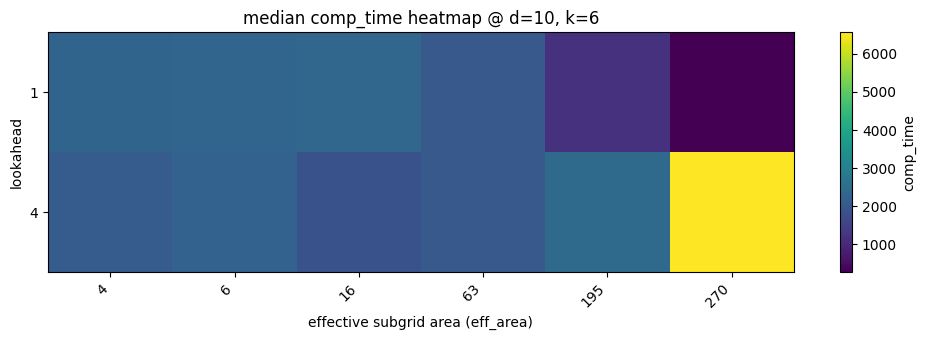

In [20]:
D_FIXED=10
K_FIXED=6
# reuse the same D_FIXED, K_FIXED, Y_METRIC if desired
sub = df[(df["d"] == D_FIXED) & (df["k"] == K_FIXED) & df[Y_METRIC].notna()]
if sub.empty:
    print("no data for this slice")
else:
    mat = (
        sub
        .groupby(["lookahead", "eff_area"], as_index=False)[Y_METRIC]
        .median()
        .pivot(index="lookahead", columns="eff_area", values=Y_METRIC)
    )

    fig, ax = plt.subplots(figsize=(10, 3 + 0.25 * len(mat)))
    im = ax.imshow(mat.values, aspect="auto", interpolation="nearest")

    ax.set_yticks(range(len(mat.index)))
    ax.set_yticklabels(mat.index)
    ax.set_xticks(range(len(mat.columns)))
    ax.set_xticklabels(mat.columns, rotation=45, ha="right")

    ax.set_xlabel("effective subgrid area (eff_area)")
    ax.set_ylabel("lookahead")
    ax.set_title(f"median {Y_METRIC} heatmap @ d={D_FIXED}, k={K_FIXED}")

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(Y_METRIC)
    plt.tight_layout()
    plt.show()

Cell D: plotting 10 effective areas at k=2, la=4
Areas: [4, 6, 12, 16, 36, 64, 90, 144, 196, 240]


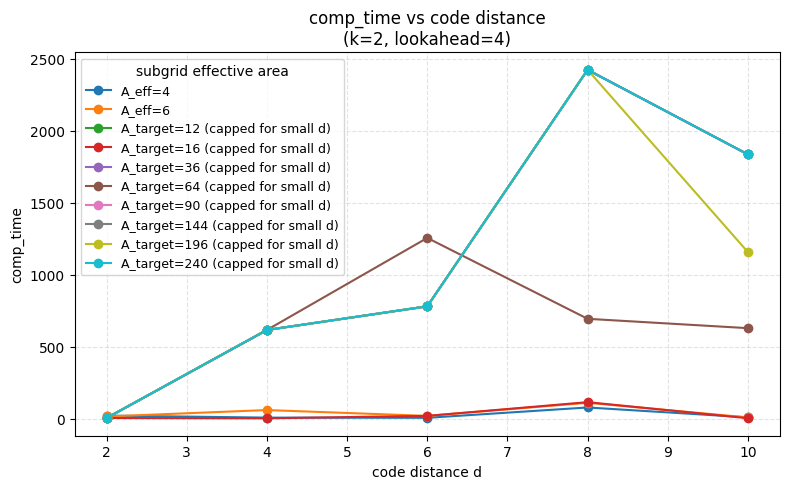

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- knobs you can tweak ----------
LA_FIXED = 4        # which lookahead to slice on
K_FIXED2 = 2        # which trap capacity to slice on
METRIC   = "comp_time"   # what to plot vs d ("comp_time" or "exec_time")
MAX_LINES = None    # set e.g. 6 to only plot first 6 areas, or None for all
# ----------------------------------------


# Use latest results table; change logic here if you renamed things
frame = df2.copy() if "df2" in globals() else df.copy()

sub = frame[(frame["lookahead"] == LA_FIXED) & (frame["k"] == K_FIXED2)].copy()
sub = sub.dropna(subset=[METRIC])

if sub.empty:
    print("no data for this slice")
else:
    # All effective areas we’ve actually seen in this slice
    target_areas = sorted(sub["eff_area"].unique())
    if MAX_LINES is not None:
        target_areas = target_areas[:MAX_LINES]

    print(f"Cell D: plotting {len(target_areas)} effective areas at k={K_FIXED2}, la={LA_FIXED}")
    print("Areas:", target_areas)

    fig, ax = plt.subplots(figsize=(8, 5))

    # group once by d for efficiency
    by_d = {d: df_d for d, df_d in sub.groupby("d")}
    all_ds = sorted(by_d.keys())

    for A_target in target_areas:
        rows_for_line = []

        for d in all_ds:
            df_d = by_d[d]

            # 1) try to use exactly this eff_area
            df_exact = df_d[df_d["eff_area"] == A_target]

            if not df_exact.empty:
                used = df_exact
                used_eff = A_target
            else:
                # 2) otherwise, fall back to the largest effective area
                max_eff = df_d["eff_area"].max()
                used = df_d[df_d["eff_area"] == max_eff]
                used_eff = max_eff

            if used.empty:
                # should not happen, but be defensive
                continue

            vals = used[METRIC].values
            rows_for_line.append({
                "d":    d,
                "med":  float(np.nanmedian(vals)),
                "p25":  float(np.nanpercentile(vals, 25)),
                "p75":  float(np.nanpercentile(vals, 75)),
                "used_eff": int(used_eff),
            })

        if not rows_for_line:
            continue

        gg = pd.DataFrame(rows_for_line).sort_values("d")

        # Label shows the target area and notes if we had to cap for some d
        if any(gg["used_eff"] != A_target):
            label = f"A_target={A_target} (capped for small d)"
        else:
            label = f"A_eff={A_target}"

        ax.plot(gg["d"], gg["med"], marker="o", label=label)
        ax.fill_between(gg["d"], gg["p25"], gg["p75"], alpha=0.18)

    ax.set_xlabel("code distance d")
    ax.set_ylabel(METRIC)
    ax.set_title(f"{METRIC} vs code distance\n(k={K_FIXED2}, lookahead={LA_FIXED})")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(title="subgrid effective area", fontsize=9)
    plt.tight_layout()
    plt.show()

Cell D: plotting 6 effective areas at k=2, la=4
Areas: [4, 6, 12, 36, 90, 144]


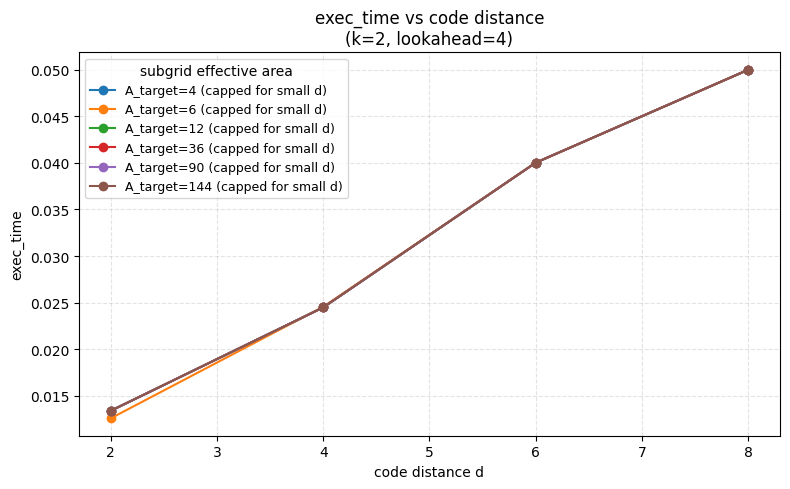

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- knobs you can tweak ----------
LA_FIXED = 4        # which lookahead to slice on
K_FIXED2 = 2        # which trap capacity to slice on
METRIC   = "exec_time"   # what to plot vs d ("comp_time" or "exec_time")
MAX_LINES = None    # set e.g. 6 to only plot first 6 areas, or None for all
# ----------------------------------------


# Use latest results table; change logic here if you renamed things
frame = df2.copy() if "df2" in globals() else df.copy()

sub = frame[(frame["lookahead"] == LA_FIXED) & (frame["k"] == K_FIXED2)].copy()
sub = sub.dropna(subset=[METRIC])

if sub.empty:
    print("no data for this slice")
else:
    # All effective areas we’ve actually seen in this slice
    target_areas = sorted(sub["eff_area"].unique())
    if MAX_LINES is not None:
        target_areas = target_areas[:MAX_LINES]

    print(f"Cell D: plotting {len(target_areas)} effective areas at k={K_FIXED2}, la={LA_FIXED}")
    print("Areas:", target_areas)

    fig, ax = plt.subplots(figsize=(8, 5))

    # group once by d for efficiency
    by_d = {d: df_d for d, df_d in sub.groupby("d")}
    all_ds = sorted(by_d.keys())

    for A_target in target_areas:
        rows_for_line = []

        for d in all_ds:
            df_d = by_d[d]

            # 1) try to use exactly this eff_area
            df_exact = df_d[df_d["eff_area"] == A_target]

            if not df_exact.empty:
                used = df_exact
                used_eff = A_target
            else:
                # 2) otherwise, fall back to the largest effective area
                max_eff = df_d["eff_area"].max()
                used = df_d[df_d["eff_area"] == max_eff]
                used_eff = max_eff

            if used.empty:
                # should not happen, but be defensive
                continue

            vals = used[METRIC].values
            rows_for_line.append({
                "d":    d,
                "med":  float(np.nanmedian(vals)),
                "p25":  float(np.nanpercentile(vals, 25)),
                "p75":  float(np.nanpercentile(vals, 75)),
                "used_eff": int(used_eff),
            })

        if not rows_for_line:
            continue

        gg = pd.DataFrame(rows_for_line).sort_values("d")

        # Label shows the target area and notes if we had to cap for some d
        if any(gg["used_eff"] != A_target):
            label = f"A_target={A_target} (capped for small d)"
        else:
            label = f"A_eff={A_target}"

        ax.plot(gg["d"], gg["med"], marker="o", label=label)
        ax.fill_between(gg["d"], gg["p25"], gg["p75"], alpha=0.18)

    ax.set_xlabel("code distance d")
    ax.set_ylabel(METRIC)
    ax.set_title(f"{METRIC} vs code distance\n(k={K_FIXED2}, lookahead={LA_FIXED})")
    ax.grid(True, linestyle="--", alpha=0.35)
    ax.legend(title="subgrid effective area", fontsize=9)
    plt.tight_layout()
    plt.show()

Cell D (new): k=2, lookaheads present: [1, 4]


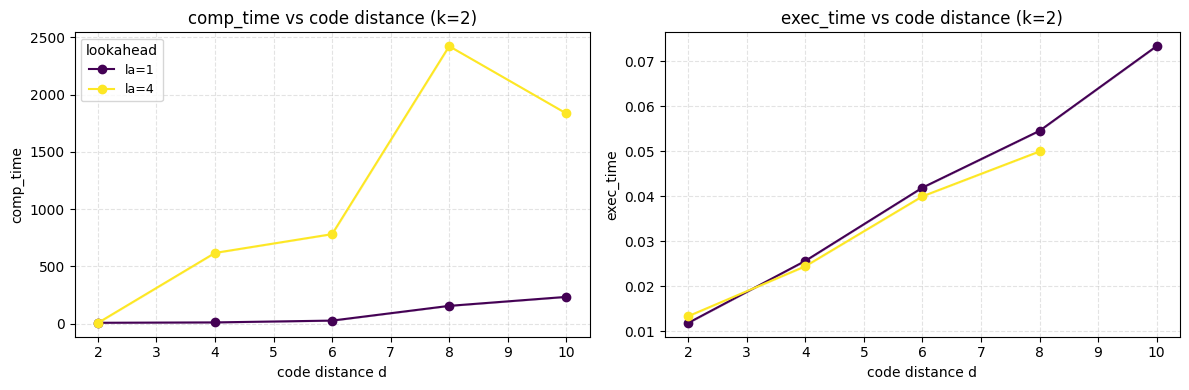

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- knobs you can tweak ----------
K_FIXED2   = 2  # which trap capacity to slice on
METRICS    = ["comp_time", "exec_time"]  # we’ll plot both vs d
USE_D_QUANTILES = True                 # show median + [p25, p75] bands
# ----------------------------------------


# Use latest results table; change logic here if you renamed things
frame = df2.copy() if "df2" in globals() else df.copy()

# Keep only this k and rows where at least one metric is non-NaN
sub = frame[(frame["k"] == K_FIXED2)].copy()
sub = sub.dropna(subset=METRICS, how="all")

if sub.empty:
    print(f"no data for k={K_FIXED2}")
else:
    # For each (lookahead, d), choose rows with the *largest* effective area at that point.
    # This gives you one “best” subgrid per (d, la) to plot.
    grouped = []
    for (la, d), df_ld in sub.groupby(["lookahead", "d"]):
        max_area = df_ld["eff_area"].max()
        df_ld_max = df_ld[df_ld["eff_area"] == max_area]

        if df_ld_max.empty:
            continue

        row = {"lookahead": la, "d": d}
        for metric in METRICS:
            vals = df_ld_max[metric].dropna().values
            if len(vals) == 0:
                row[f"{metric}_med"] = np.nan
                row[f"{metric}_p25"] = np.nan
                row[f"{metric}_p75"] = np.nan
            else:
                row[f"{metric}_med"] = float(np.nanmedian(vals))
                if USE_D_QUANTILES:
                    row[f"{metric}_p25"] = float(np.nanpercentile(vals, 25))
                    row[f"{metric}_p75"] = float(np.nanpercentile(vals, 75))
        row["eff_area_used"] = int(max_area)
        grouped.append(row)

    if not grouped:
        print(f"no usable (d, lookahead) points for k={K_FIXED2}")
    else:
        gdf = pd.DataFrame(grouped).sort_values(["lookahead", "d"])

        las = sorted(gdf["lookahead"].unique())
        print(f"Cell D (new): k={K_FIXED2}, lookaheads present:", las)

        # One subplot per metric: comp_time vs d, exec_time vs d
        fig, axes = plt.subplots(1, len(METRICS), figsize=(6 * len(METRICS), 4), sharex=True)
        if len(METRICS) == 1:
            axes = [axes]

        colours = plt.cm.viridis(np.linspace(0, 1, len(las)))  # distinct colour per lookahead

        for color, la in zip(colours, las):
            g_la = gdf[gdf["lookahead"] == la].sort_values("d")

            for ax, metric in zip(axes, METRICS):
                med_col = f"{metric}_med"
                p25_col = f"{metric}_p25"
                p75_col = f"{metric}_p75"

                if g_la[med_col].notna().sum() == 0:
                    continue

                ax.plot(
                    g_la["d"], g_la[med_col],
                    marker="o", label=f"la={la}", color=color
                )

                if USE_D_QUANTILES and p25_col in g_la.columns and p75_col in g_la.columns:
                    ax.fill_between(
                        g_la["d"], g_la[p25_col], g_la[p75_col],
                        alpha=0.18, color=color
                    )

                ax.set_xlabel("code distance d")
                ax.set_ylabel(metric)
                ax.grid(True, linestyle="--", alpha=0.35)
                ax.set_title(f"{metric} vs code distance (k={K_FIXED2})")

        axes[0].legend(title="lookahead", fontsize=9)
        plt.tight_layout()
        plt.show()

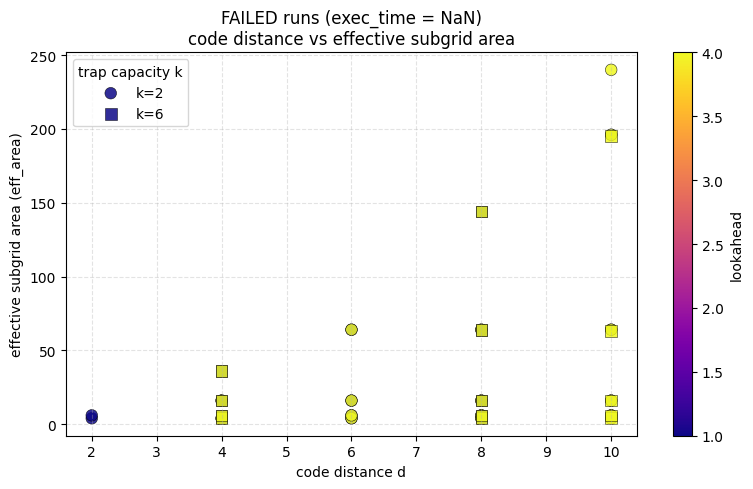

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable

# ---- choose source frame ----
frame = df2.copy() if "df2" in globals() else df.copy()

# Only plot failures: exec_time = NaN
nan_runs = frame[frame["exec_time"].isna()].copy()

if nan_runs.empty:
    print("No NaN exec_time failures found.")
else:
    # Ensure we have eff_area
    if "eff_area" not in nan_runs.columns:
        if {"subgrid_width", "subgrid_height"}.issubset(nan_runs.columns):
            nan_runs["eff_area"] = nan_runs["subgrid_width"] * nan_runs["subgrid_height"]
        elif "subgrid_area_req" in nan_runs.columns:
            nan_runs["eff_area"] = nan_runs["subgrid_area_req"]
        else:
            raise ValueError("Cannot derive eff_area for plotting")

    # Color scale = lookahead
    las = nan_runs["lookahead"].values
    unique_la = np.unique(las)
    cmap = plt.cm.plasma
    norm = plt.Normalize(vmin=min(unique_la), vmax=max(unique_la))

    # Marker shape encodes trap capacity k
    marker_map = {2: "o", 6: "s"}  # circle = k=2, square = k=6
    default_marker = "x"

    fig, ax = plt.subplots(figsize=(8, 5))

    # Plot each k separately for different markers
    for k_val, df_k in nan_runs.groupby("k"):
        marker = marker_map.get(k_val, default_marker)
        sc = ax.scatter(
            df_k["d"],
            df_k["eff_area"],
            c=df_k["lookahead"],
            cmap=cmap,
            norm=norm,
            marker=marker,
            edgecolors="black",
            linewidths=0.4,
            s=70,
            alpha=0.85,
            label=f"k={k_val}",
        )

    # Axis labels and formatting
    ax.set_xlabel("code distance d")
    ax.set_ylabel("effective subgrid area (eff_area)")
    ax.set_title("FAILED runs (exec_time = NaN)\ncode distance vs effective subgrid area")
    ax.grid(True, linestyle="--", alpha=0.35)

    # Colorbar for lookahead
    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax)
    cbar.set_label("lookahead")

    ax.legend(title="trap capacity k")
    plt.tight_layout()
    plt.show()

In [66]:
import numpy as np
import pandas as pd

# df should contain at least: eff_area, lookahead, d, k, comp_time, exec_time, (optional) logical_rate
metrics_to_check = ["comp_time", "exec_time", "logical_rate"]
min_points = 4  # only compute correlations if we have at least this many samples

corr_rows = []

for metric in metrics_to_check:
    if metric not in df.columns:
        continue

    base = df[["eff_area", "lookahead", "d", "k", metric]].dropna()
    if len(base) < min_points:
        continue

    # ------- global (ALL, ALL) -------
    corr_rows.append({
        "metric": metric,
        "d": "ALL",
        "k": "ALL",
        "pearson_area":   base["eff_area"].corr(base[metric], method="pearson"),
        "spearman_area":  base["eff_area"].corr(base[metric], method="spearman"),
        "pearson_la":     base["lookahead"].corr(base[metric], method="pearson"),
        "spearman_la":    base["lookahead"].corr(base[metric], method="spearman"),
        "n_points":       len(base),
    })

    # ------- per (d, k) -------
    for (d_val, k_val), g in base.groupby(["d", "k"]):
        if len(g) < min_points:
            continue
        corr_rows.append({
            "metric": metric,
            "d": d_val,
            "k": k_val,
            "pearson_area":   g["eff_area"].corr(g[metric], method="pearson"),
            "spearman_area":  g["eff_area"].corr(g[metric], method="spearman"),
            "pearson_la":     g["lookahead"].corr(g[metric], method="pearson"),
            "spearman_la":    g["lookahead"].corr(g[metric], method="spearman"),
            "n_points":       len(g),
        })

corr_df = pd.DataFrame(corr_rows)
display(corr_df)

,metric,d,k,pearson_area,spearman_area,pearson_la,spearman_la,n_points
0,comp_time,ALL,ALL,0.435325,0.229070,0.194051,0.109386,94
1,comp_time,2,2,-0.661659,-0.717137,0.433043,0.292770,6
2,comp_time,2,6,-0.995222,-0.975900,0.037639,0.109109,8
3,comp_time,4,2,0.569943,0.097590,0.373399,0.000000,8
4,comp_time,4,6,0.606874,-0.146385,-0.384013,-0.654654,8
5,comp_time,6,2,0.534243,0.787786,0.479026,0.243709,10
6,comp_time,6,6,-0.556485,-0.615457,0.686259,0.661495,10
7,comp_time,8,2,0.649087,0.467748,0.426900,0.591864,10
8,comp_time,8,6,-0.525527,-0.640076,0.029350,0.174078,10
9,comp_time,10,2,0.770406,0.579538,0.387606,0.386244,12


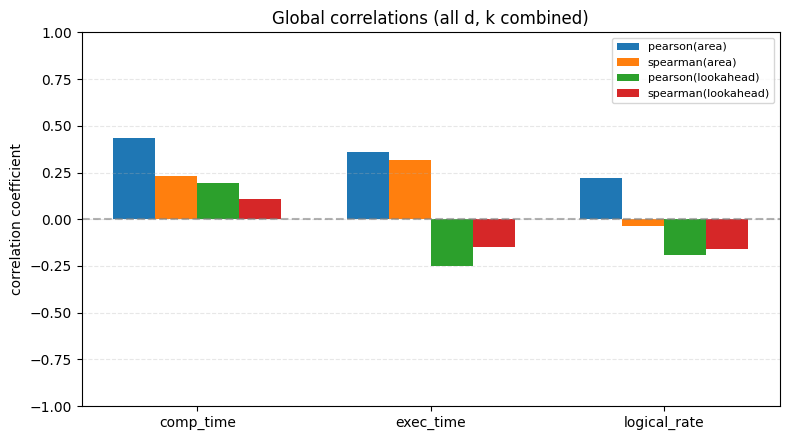

In [67]:
import matplotlib.pyplot as plt
import numpy as np

if corr_df.empty:
    print("corr_df is empty")
else:
    global_corr = corr_df[(corr_df["d"] == "ALL") & (corr_df["k"] == "ALL")].copy()
    if global_corr.empty:
        print("No global (ALL,ALL) rows in corr_df")
    else:
        metrics = global_corr["metric"].tolist()

        # 4 correlation types per metric
        cols = ["pearson_area", "spearman_area", "pearson_la", "spearman_la"]
        labels = [
            "pearson(area)",
            "spearman(area)",
            "pearson(lookahead)",
            "spearman(lookahead)",
        ]

        x = np.arange(len(metrics))
        width = 0.18

        fig, ax = plt.subplots(figsize=(8, 4.5))

        for j, (col, lab) in enumerate(zip(cols, labels)):
            vals = global_corr[col].values
            ax.bar(x + (j - 1.5) * width, vals, width=width, label=lab)

        ax.axhline(0.0, color="grey", linestyle="--", alpha=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        ax.set_ylim(-1, 1)
        ax.set_ylabel("correlation coefficient")
        ax.set_title("Global correlations (all d, k combined)")
        ax.legend(fontsize=8)
        ax.grid(True, axis="y", linestyle="--", alpha=0.3)
        plt.tight_layout()
        plt.show()

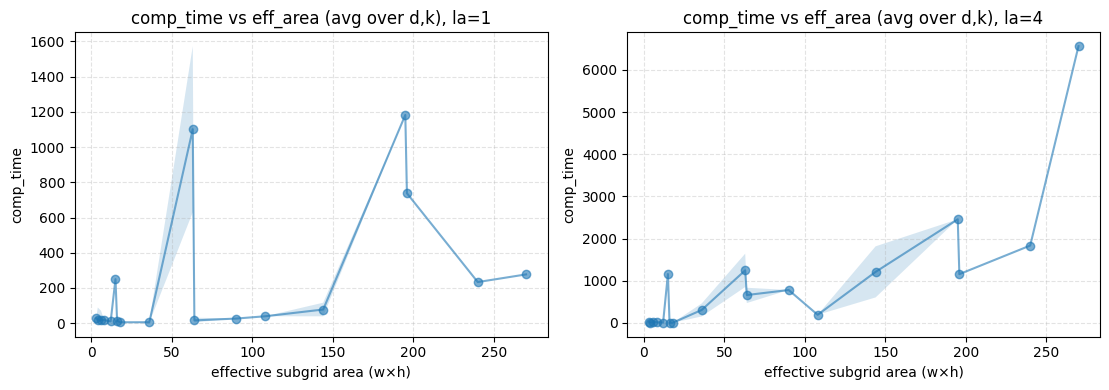

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- knobs ----------
metric = "comp_time"   # or "exec_time"
# ---------------------------

df = df2.copy() if "df2" in globals() else df.copy()

# ensure eff_area exists (it should from your run code)
if "eff_area" not in df.columns:
    if {"subgrid_width", "subgrid_height"}.issubset(df.columns):
        df["eff_area"] = df["subgrid_width"] * df["subgrid_height"]
    elif "subgrid_area_req" in df.columns:
        df["eff_area"] = df["subgrid_area_req"]
    else:
        raise ValueError("Cannot derive eff_area in this frame")

# guard for is_fullgrid
if "is_fullgrid" not in df.columns:
    df["is_fullgrid"] = 0

sub = df[df[metric].notna()].copy()
if sub.empty:
    print(f"No data with non-NaN {metric}")
else:
    # aggregate across d and k: median + spread vs (lookahead, eff_area)
    g = (
        sub.groupby(["lookahead", "eff_area"], as_index=False)[metric]
           .agg(
               median=lambda s: np.nanmedian(s),
               p25=lambda s: np.nanpercentile(s, 25),
               p75=lambda s: np.nanpercentile(s, 75),
           )
           .merge(
               sub.groupby(["lookahead", "eff_area"], as_index=False)["is_fullgrid"]
                  .mean()
                  .rename(columns={"is_fullgrid": "frac_full"}),
               on=["lookahead", "eff_area"],
               how="left",
           )
    )

    # (optional) add count if you want it
    counts = (
        sub.groupby(["lookahead", "eff_area"], as_index=False)[metric]
           .size()
           .rename(columns={"size": "n"})
    )
    g = g.merge(counts, on=["lookahead", "eff_area"], how="left")

    g = g.sort_values(["lookahead", "eff_area"])

    las = sorted(g["lookahead"].unique())
    ncol = min(4, max(1, len(las)))
    nrow = int(np.ceil(len(las) / ncol))
    fig, axes = plt.subplots(
        nrow, ncol,
        figsize=(5.6 * ncol, 4.0 * nrow),
        squeeze=False
    )

    for ax, la in zip(axes.flat, las):
        gg = g[g["lookahead"] == la].sort_values("eff_area")
        if gg.empty:
            ax.set_visible(False)
            continue

        # dim the curve gradually as it becomes mostly full-grid
        # (frac_full ~ fraction of samples at that eff_area that are full-grid)
        alpha_line = 1.0 - 0.4 * gg["frac_full"].clip(0, 1)

        ax.plot(
            gg["eff_area"],
            gg["median"],
            marker="o",
            label=f"la={la}",
            alpha=float(alpha_line.iloc[-1]),
        )
        ax.fill_between(
            gg["eff_area"],
            gg["p25"],
            gg["p75"],
            alpha=0.18,
        )

        ax.set_title(f"{metric} vs eff_area (avg over d,k), la={la}")
        ax.set_xlabel("effective subgrid area (w×h)")
        ax.set_ylabel(metric)
        ax.grid(True, linestyle="--", alpha=0.35)
        # you can uncomment this if areas span many orders of magnitude
        # ax.set_xscale("log")

    # hide unused axes
    for ax in axes.flat[len(las):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

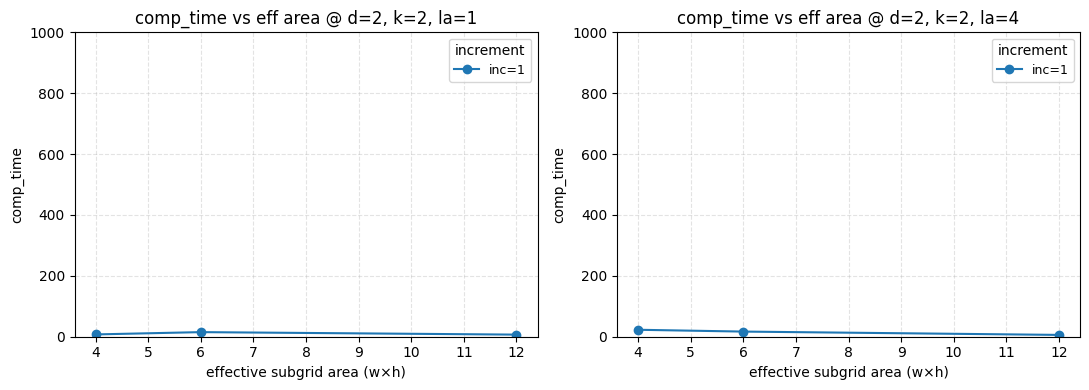

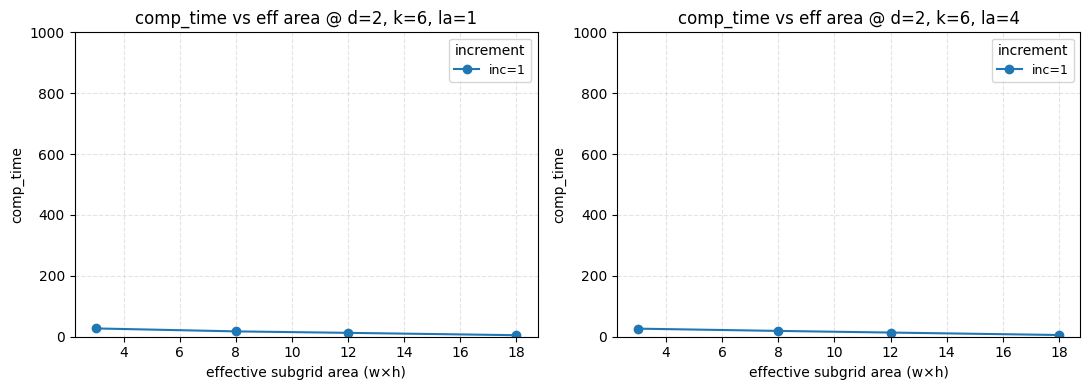

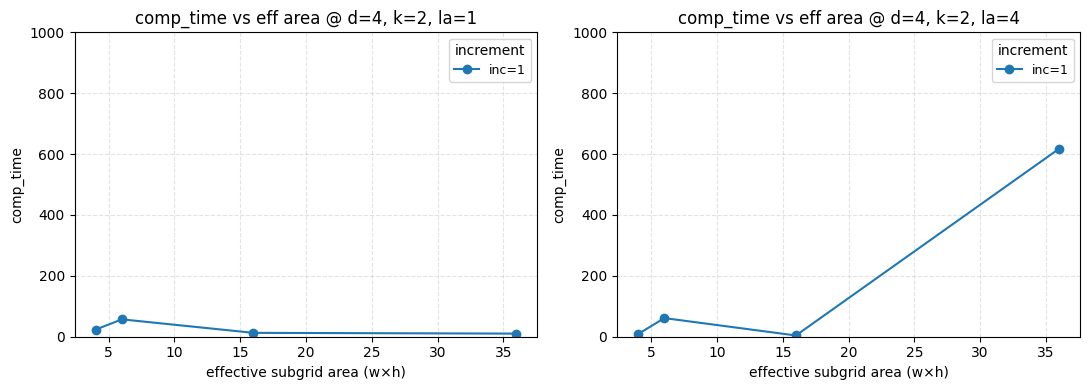

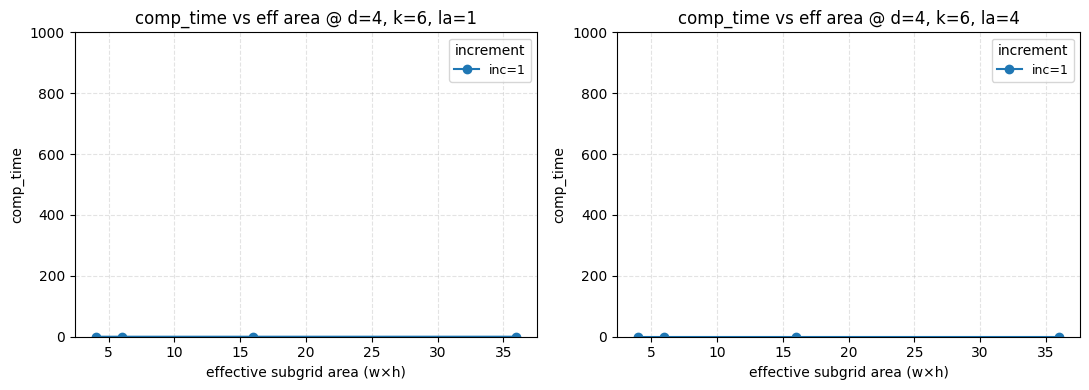

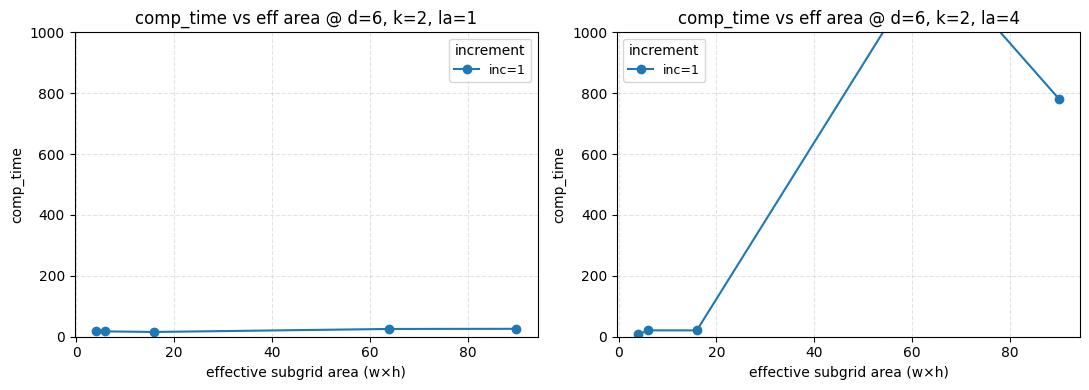

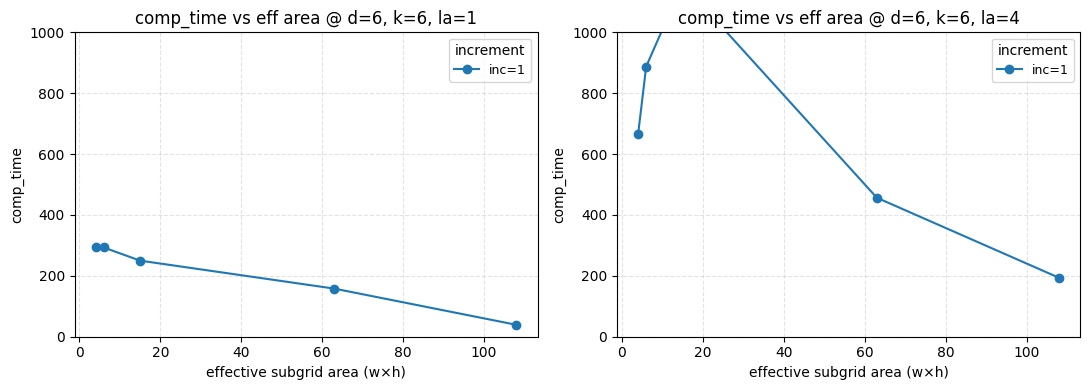

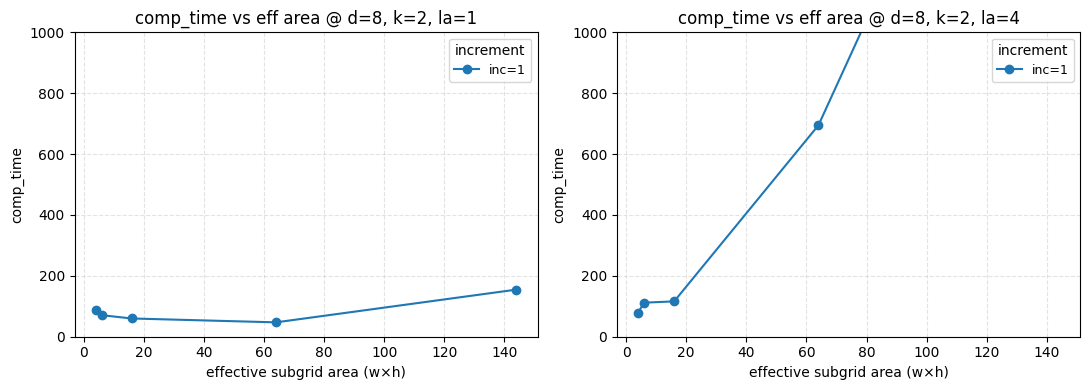

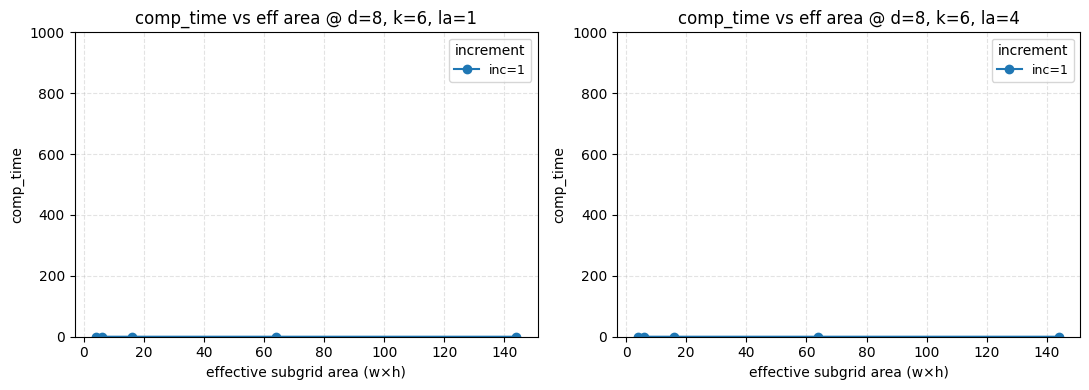

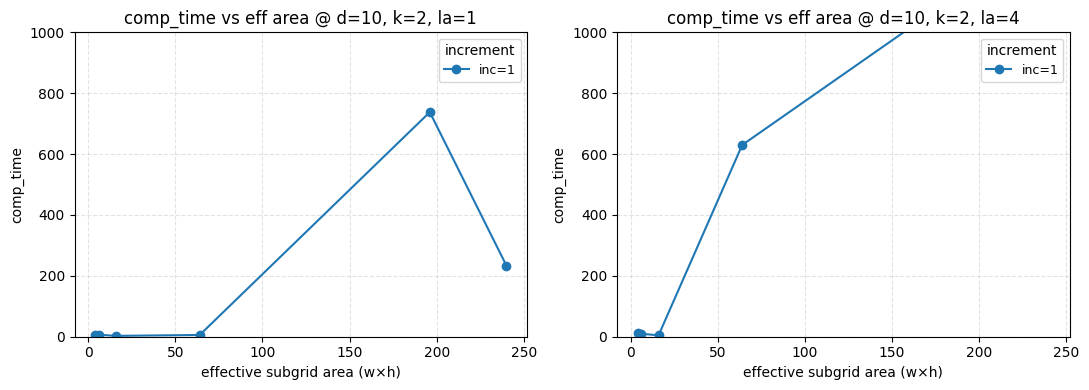

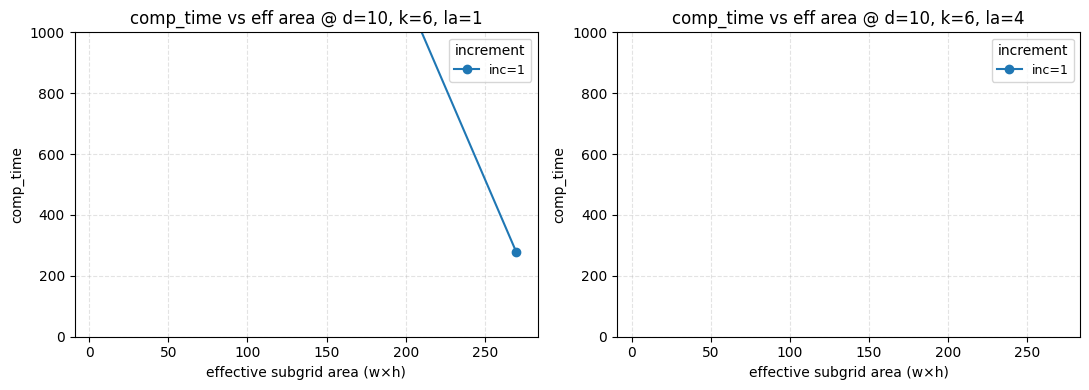

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- knobs you can tweak ----------
# list of (d, k) pairs you want figures for
DK_PAIRS = [(2, 2), (2,6), (4, 2), (4,6), (6, 2),(6,6), (8,2), (8, 6),(10,2),(10,6)]   # edit / extend as you like

Y_METRIC = "comp_time"    # "comp_time" or "exec_time"
# ----------------------------------------


# Make a working copy and ensure eff_area exists
df_eff_plot = df_eff.copy()
if "eff_area" not in df_eff_plot.columns:
    df_eff_plot["eff_area"] = df_eff_plot["eff_width"] * df_eff_plot["eff_height"]

med_col = f"{Y_METRIC}_med"
p25_col = f"{Y_METRIC}_p25"
p75_col = f"{Y_METRIC}_p75"

if med_col not in df_eff_plot.columns:
    raise ValueError(f"{med_col} not found in df_eff; did you build df_eff with that metric?")

for (D_FIXED, K_FIXED) in DK_PAIRS:
    sub = df_eff_plot[
        (df_eff_plot["d"] == D_FIXED) &
        (df_eff_plot["k"] == K_FIXED) &
        df_eff_plot[med_col].notna()
    ].copy()

    if sub.empty:
        print(f"[SKIP] no data for d={D_FIXED}, k={K_FIXED}")
        continue

    # if subgrid_increment is missing (e.g. new experiments), fake a single group
    if "subgrid_increment" not in sub.columns:
        sub["subgrid_increment"] = 1

    las = sorted(sub["lookahead"].unique())
    ncol = min(3, max(1, len(las)))
    nrow = int(np.ceil(len(las) / ncol))

    fig, axes = plt.subplots(
        nrow, ncol,
        figsize=(5.5 * ncol, 4 * nrow),
        squeeze=False
    )

    for ax, la in zip(axes.flat, las):
        gg = sub[sub["lookahead"] == la].copy()
        if gg.empty:
            ax.axis("off")
            continue

        gg = gg.sort_values("eff_area")

        for inc, grp in gg.groupby("subgrid_increment"):
            grp = grp.sort_values("eff_area")

            ax.plot(
                grp["eff_area"],
                grp[med_col],
                marker="o",
                label=f"inc={int(inc)}"
            )
            # if you have p25/p75, add spread bands
            if p25_col in grp.columns and p75_col in grp.columns:
                ax.fill_between(
                    grp["eff_area"],
                    grp[p25_col],
                    grp[p75_col],
                    alpha=0.2
                )

        ax.set_title(f"{Y_METRIC} vs eff area @ d={D_FIXED}, k={K_FIXED}, la={la}")
        ax.set_xlabel("effective subgrid area (w×h)")
        ax.set_ylabel(Y_METRIC)
        ax.grid(True, linestyle="--", alpha=0.35)
        ax.legend(title="increment", fontsize=9)
        ax.set_ylim(0, 1000)

    # blank unused axes if any
    for ax in axes.flat[len(las):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
from src.compiler.qccd_ion_routing import *
from src.simulator.qccd_circuit import *
d = 7

# safe to have either barriers or go back
barrierThreshold = np.inf
goBackThreshold = 0
for trapCapacity in [2]:

    circuit = QCCDCircuit.generated(
        "surface_code:rotated_memory_z",
        rounds=1,
        distance=d,
    )
    nqubitsNeeded = 2 * d**2 - 1

    nrowsNeeded = int(np.ceil(np.sqrt(nqubitsNeeded)))
    ncolsNeeded = int(np.ceil(nrowsNeeded/trapCapacity))
    subgridsize=(nrowsNeeded,nrowsNeeded,1)
    lookahead=4

    # wiseArch = QCCDWiseArch(m=int(np.sqrt(trapCapacity*nqubitsNeeded/2))+1, n=int(np.sqrt(2*nqubitsNeeded/trapCapacity))+1, k=trapCapacity)
    wiseArch =QCCDWiseArch(m=ncolsNeeded, n=nrowsNeeded, k=trapCapacity)
    arch, (instructions, opBarriers) = circuit.processCircuitWiseArch(wiseArch=wiseArch)
    
    arch.refreshGraph()

    fig,ax =plt.subplots()
    arch.display(fig, ax, title='map complete', showLabels=False)
    # fig.set_size_inches(arch.WINDOW_SIZE[0]*1.5, arch.WINDOW_SIZE[1]*1.5)

    opBarriers = opBarriers if trapCapacity<=barrierThreshold else []
    allOps, barriers = ionRoutingWISEArch(arch, wiseArch, instructions, lookahead=lookahead, subgridsize=subgridsize)
    parallelOpsMap = paralleliseOperationsWithBarriers(allOps, barriers)
    parallelOps = list(dict(parallelOpsMap).values())

    errs = circuit.simulate(allOps, isWISEArch=True)

    arch = circuit.resetArch()
    arch.refreshGraph()

    trapSet = set()
    junctionSet = set()
    for op in allOps:
        for c in op.involvedComponents:
            if isinstance(c, Trap):
                trapSet.add(c)
            elif isinstance(c, Junction):
                junctionSet.add(c)


    Njz = len(junctionSet) # each junction is one zone
    Nlz = len(trapSet)*trapCapacity # each trap is k zones
    Nde_lz = 10
    Nde_jz = 20
    Nse_z = 10
   

    Njz = int(np.ceil(nqubitsNeeded / (2*(trapCapacity-1))) )# 2 traps per junction
    Nlz = nqubitsNeeded-Njz
    Nde = Nde_lz*Nlz+Nde_jz*Njz
    Nse = Nse_z*(Njz+Nlz)

    Num_electrodes = Nde+Nse
    Num_DACs = Num_electrodes


    print(f"total number of qubit operations: {len(instructions)}")
    print(f"total number of operations: {len(allOps)}")
    print(f"time for operations: {max(parallelOpsMap.keys())}")
    print(f'Number of Linear Zones: {Nlz}')
    print(f"Number of Junction Zones: {Njz}")
    print(f"Number of Electrodes: {Num_electrodes}={Nse}+{Nde}")
    print(f"Errors: {errs}")


[WISE] starting binary search for D in [0, 9]
[WISE] build_structural_cnf(D=4/SAT): D_bound=4, use_wcnf=False, boundary_soft=False, n=10, m=10, R=4
        round 0: |Res_r|=0, |Free_r|=100, |P[r]|=42, |BT[r]|=0
        round 1: |Res_r|=0, |Free_r|=100, |P[r]|=43, |BT[r]|=0
        round 2: |Res_r|=0, |Free_r|=100, |P[r]|=41, |BT[r]|=0
        round 3: |Res_r|=0, |Free_r|=100, |P[r]|=42, |BT[r]|=0
[WISE] SAT worker starting (timeout=20.0s) for CNF: clauses=928440
[WISE] SAT join interrupted by user after 4.077s; terminating worker (user_abort).
[WISE]  test D=4: status=user_abort, SAT=None, vars=203700, clauses=928440, time=4.251s
[WISE] build_structural_cnf(D=7/SAT): D_bound=7, use_wcnf=False, boundary_soft=False, n=10, m=10, R=4
        round 0: |Res_r|=0, |Free_r|=100, |P[r]|=42, |BT[r]|=0
        round 1: |Res_r|=0, |Free_r|=100, |P[r]|=43, |BT[r]|=0
        round 2: |Res_r|=0, |Free_r|=100, |P[r]|=41, |BT[r]|=0
        round 3: |Res_r|=0, |Free_r|=100, |P[r]|=42, |BT[r]|=0
[WISE] S

[WISE] ions_all=72, active_ions=31, spectator_ions=41
[WISE] starting binary search for D in [0, 11]
[WISE] build_structural_cnf(D=5/SAT): D_bound=5, use_wcnf=False, boundary_soft=False, n=6, m=12, R=1
        round 0: |Res_r|=0, |Free_r|=72, |P[r]|=12, |BT[r]|=0
[WISE] SAT worker starting (timeout=360.0s) for CNF: clauses=113868
[WISE] SAT worker finished in 0.080s, SAT=True
[WISE]  test D=5: status=ok, SAT=True, vars=34920, clauses=113868, time=0.417s
[WISE] build_structural_cnf(D=2/SAT): D_bound=2, use_wcnf=False, boundary_soft=False, n=6, m=12, R=1
        round 0: |Res_r|=0, |Free_r|=72, |P[r]|=12, |BT[r]|=0
[WISE] SAT worker starting (timeout=360.0s) for CNF: clauses=127260
[WISE] SAT worker finished in 0.077s, SAT=False
[WISE]  test D=2: status=ok, SAT=False, vars=34920, clauses=127260, time=0.357s
[WISE] build_structural_cnf(D=3/SAT): D_bound=3, use_wcnf=False, boundary_soft=False, n=6, m=12, R=1
        round 0: |Res_r|=0, |Free_r|=72, |P[r]|=12, |BT[r]|=0
[WISE] SAT worker st

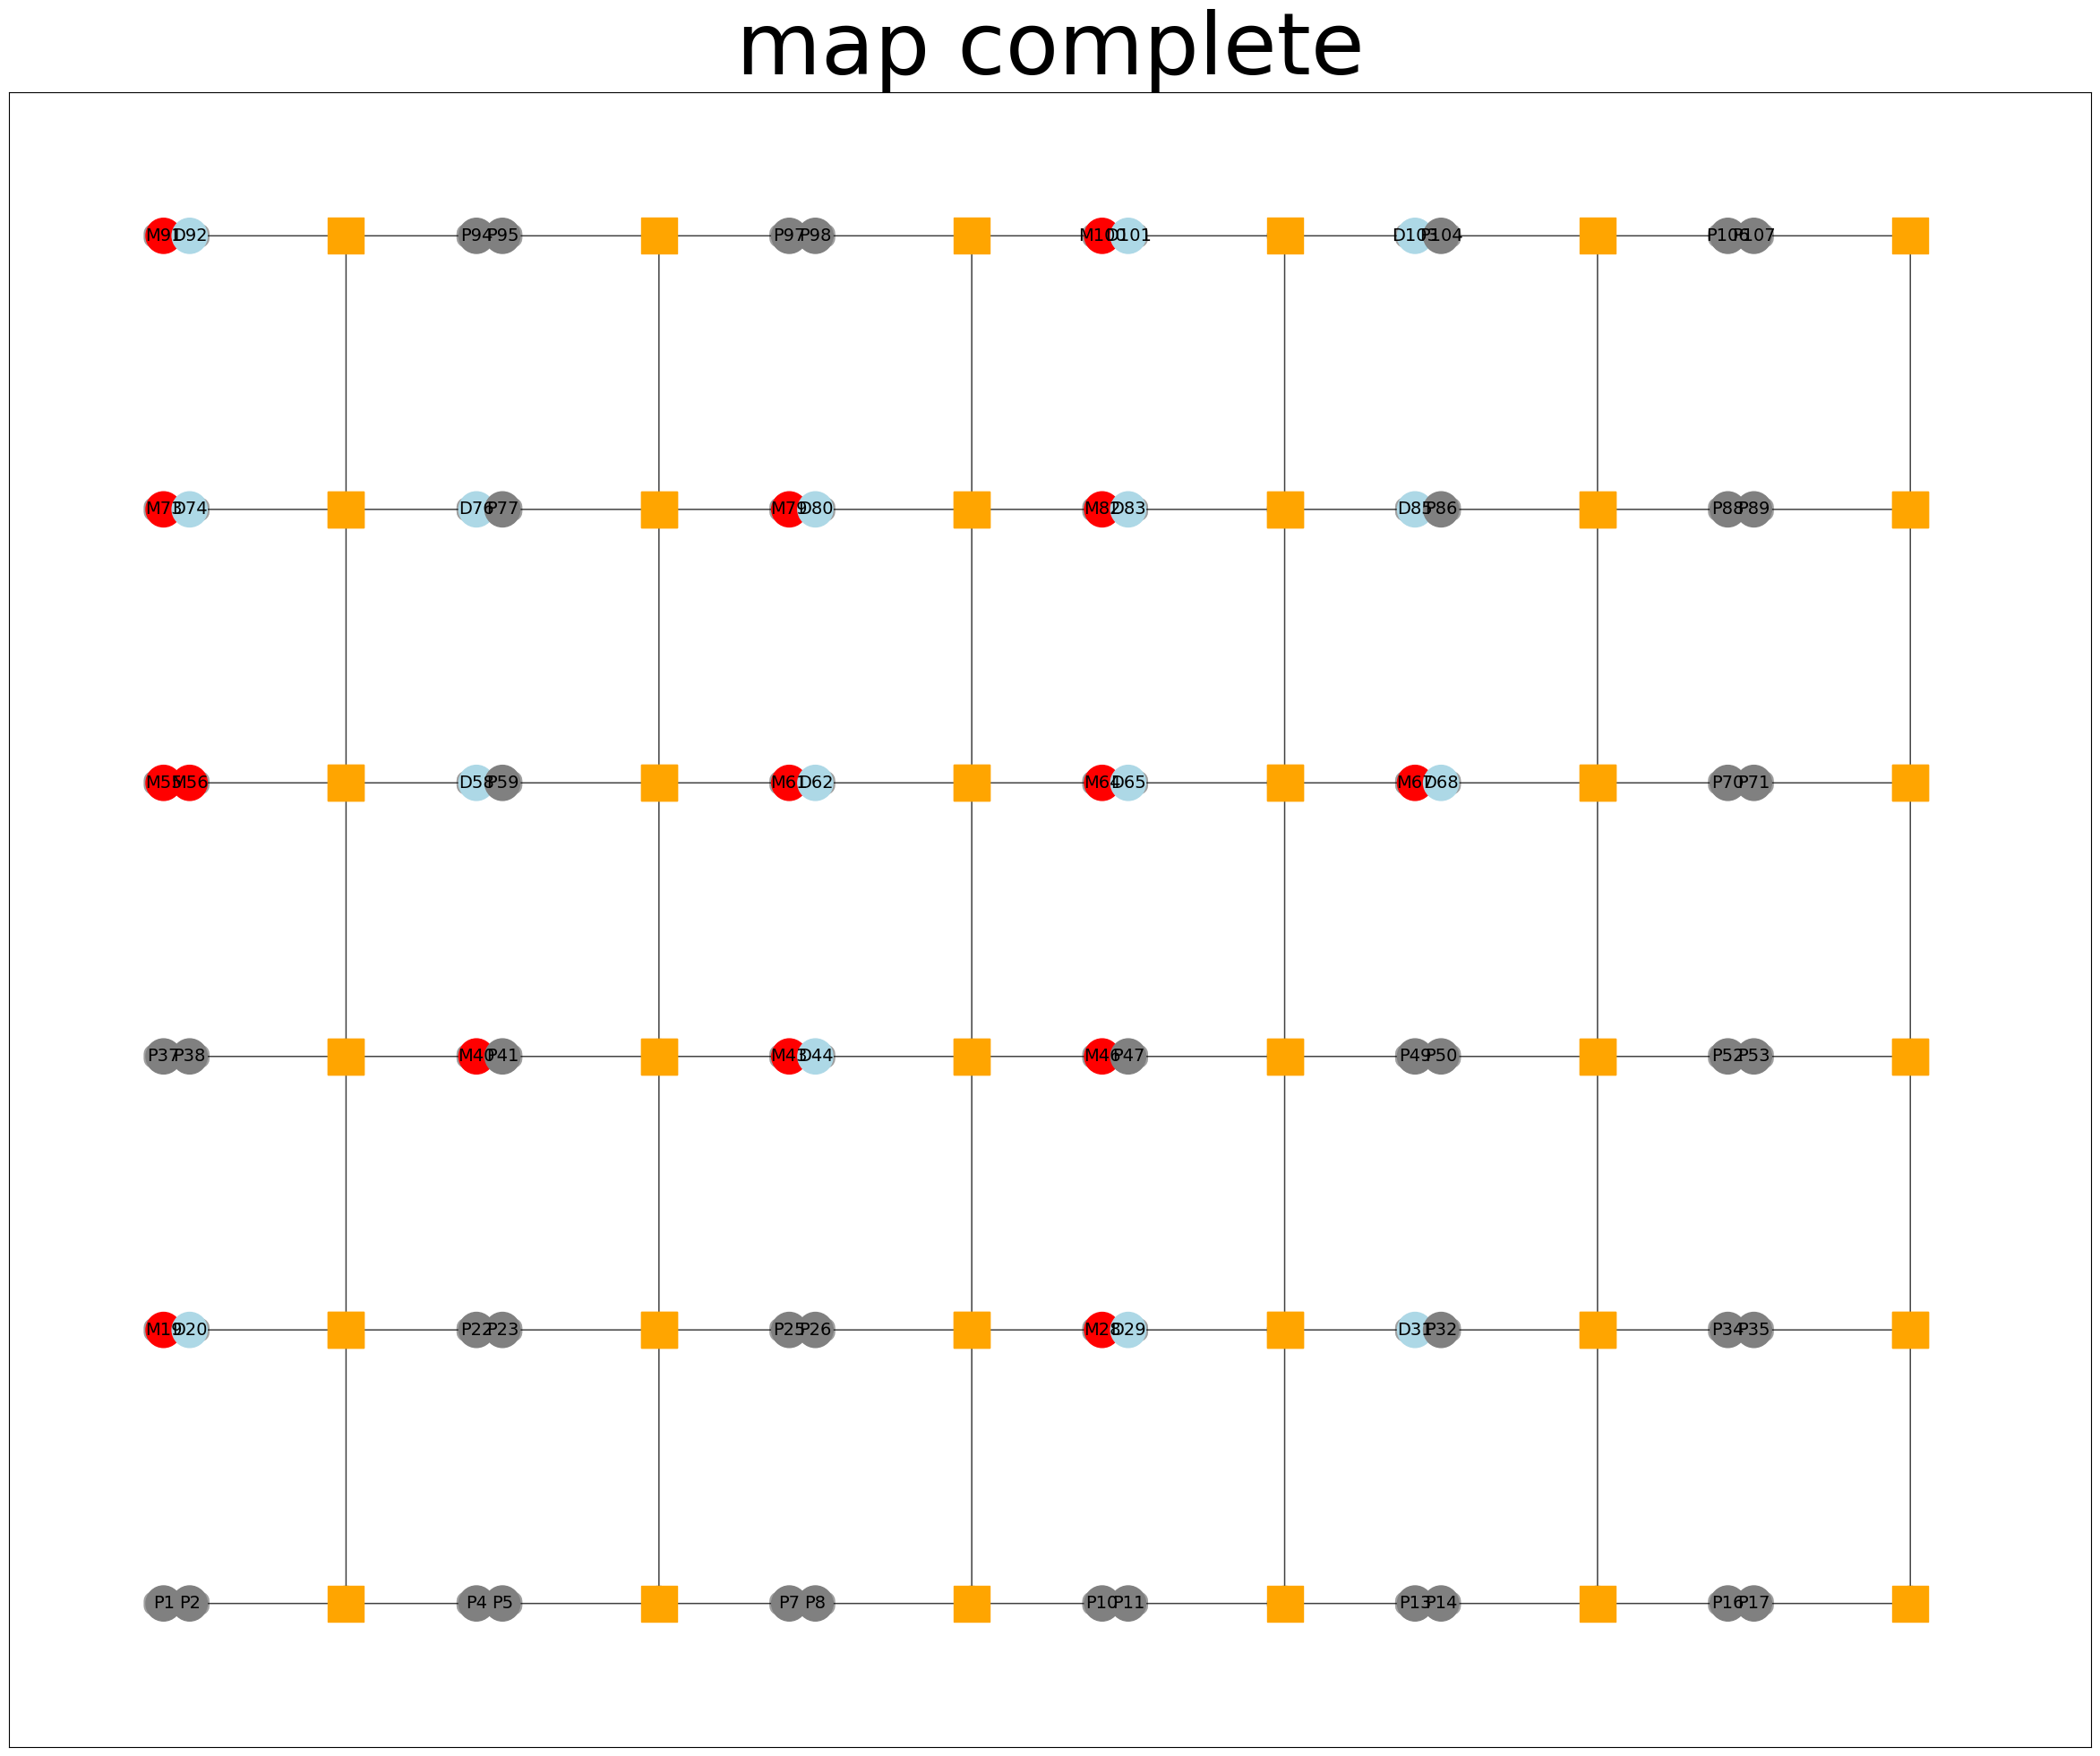

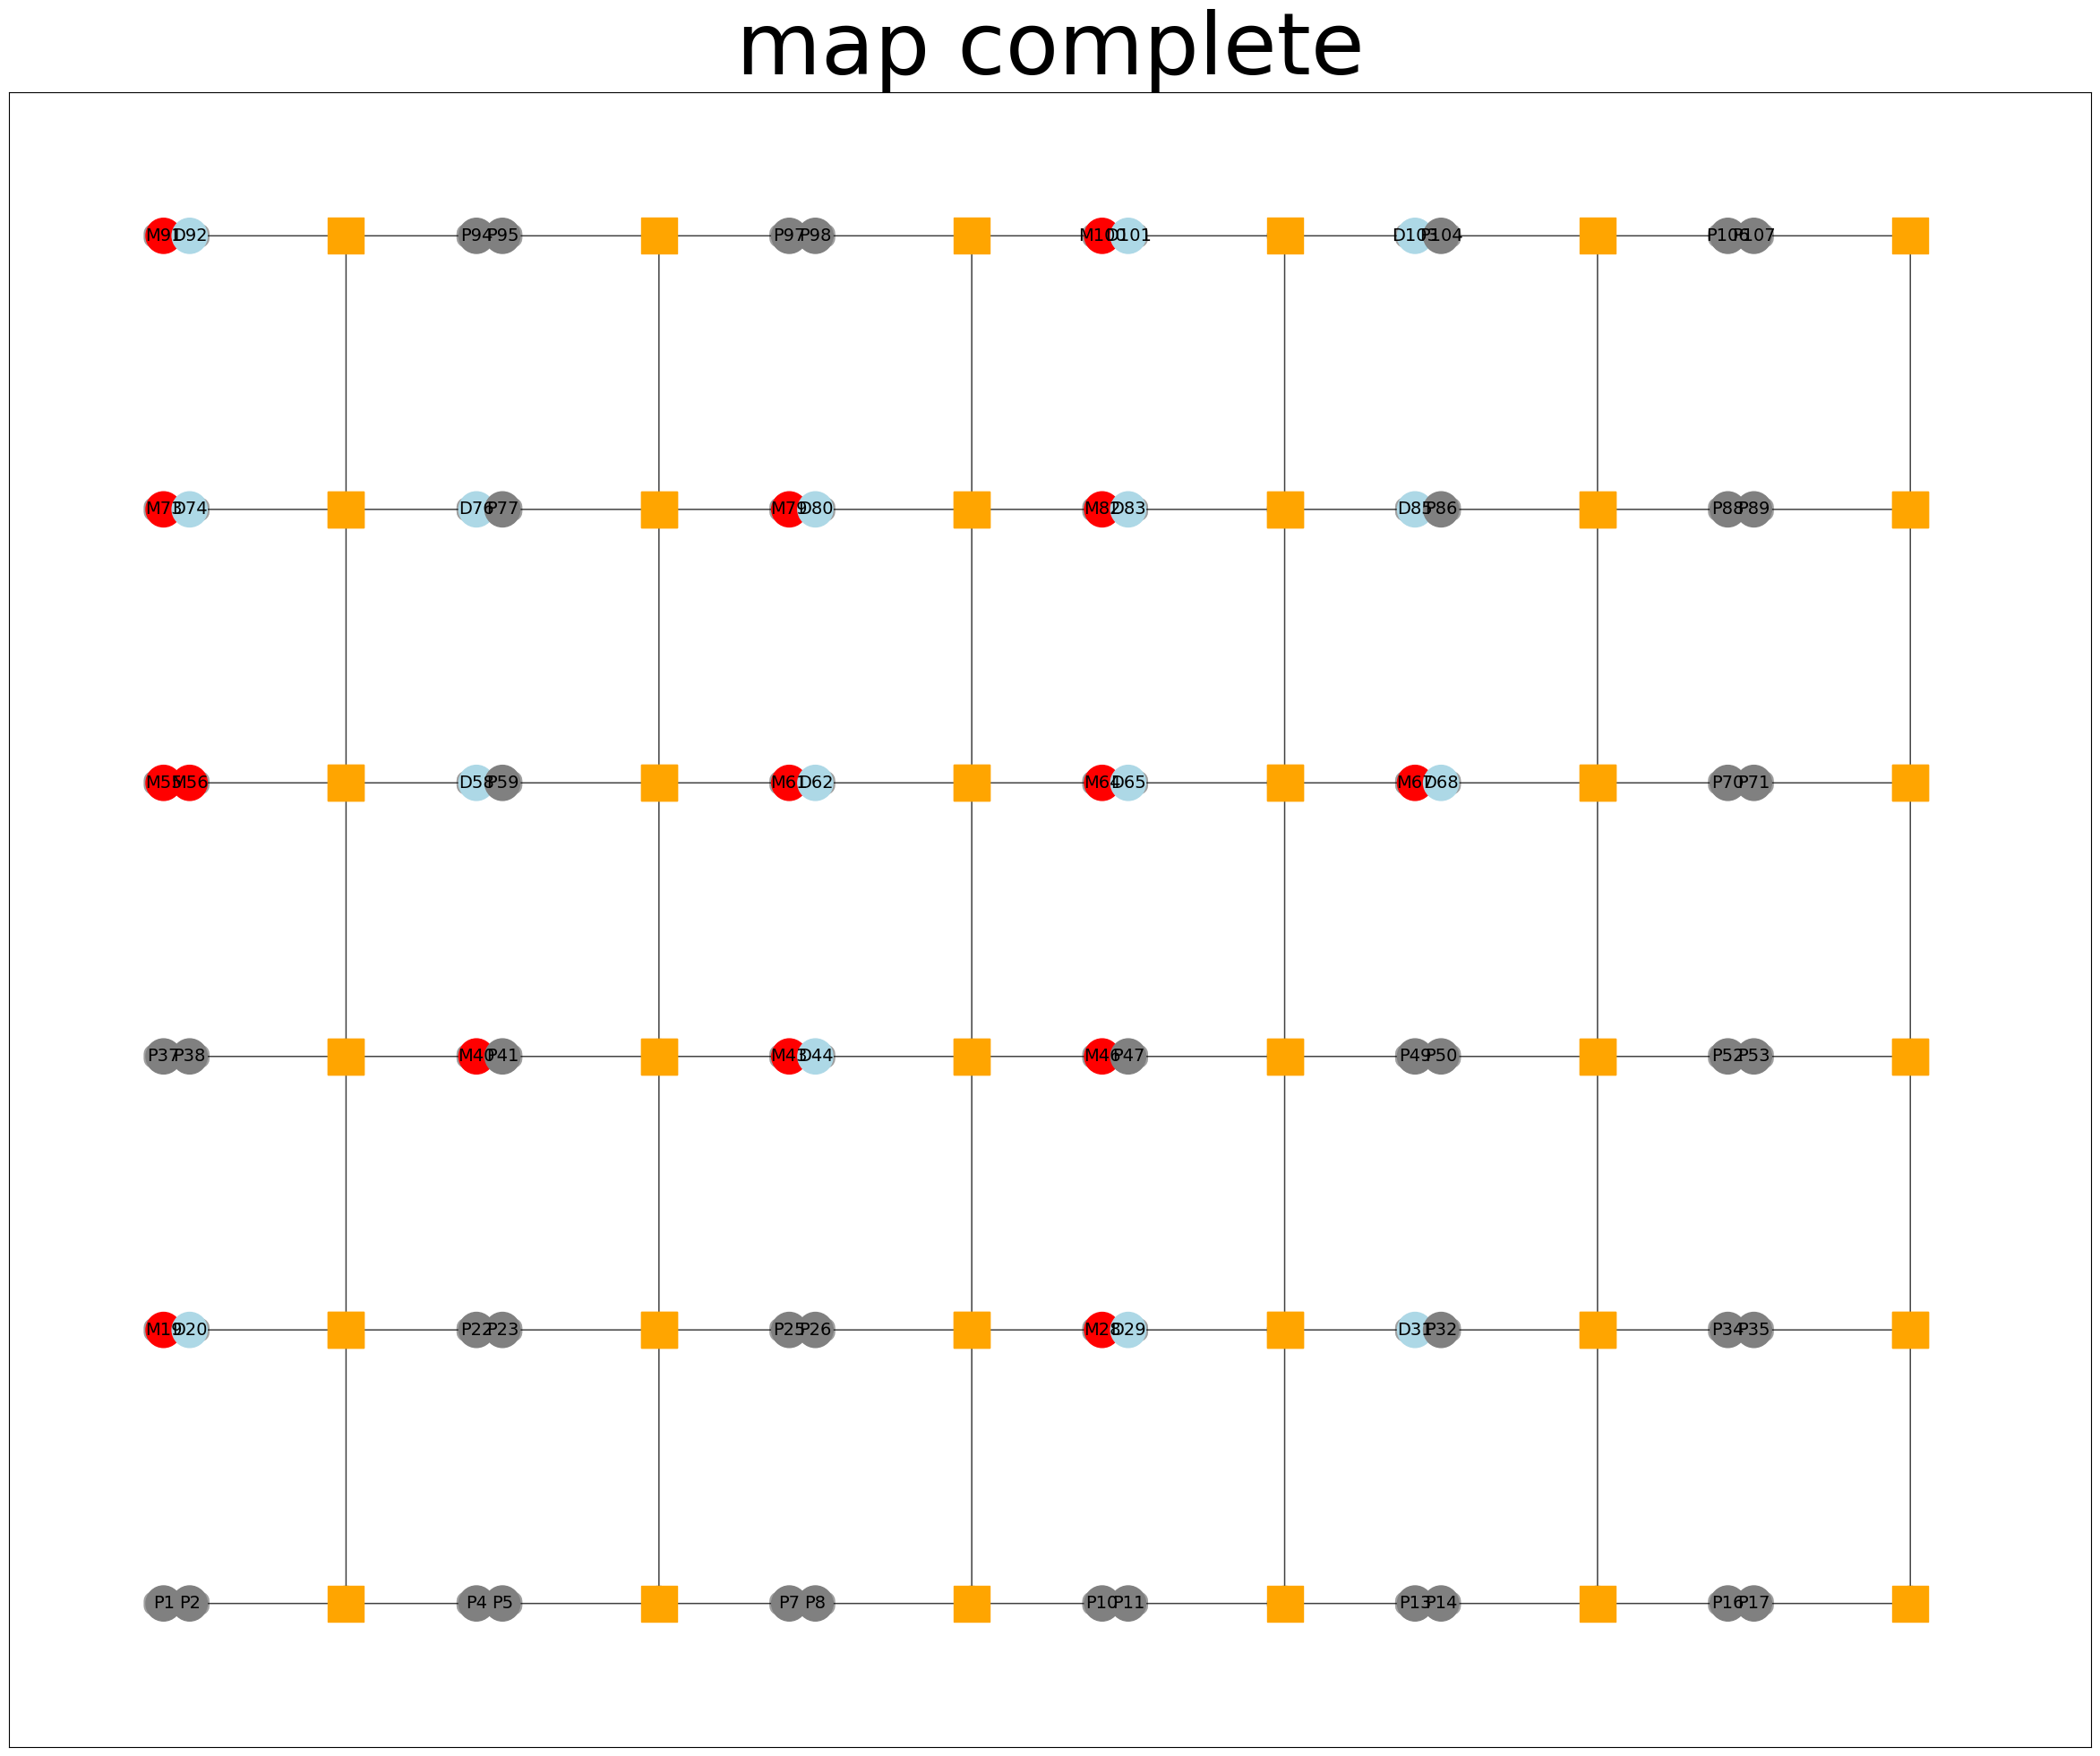

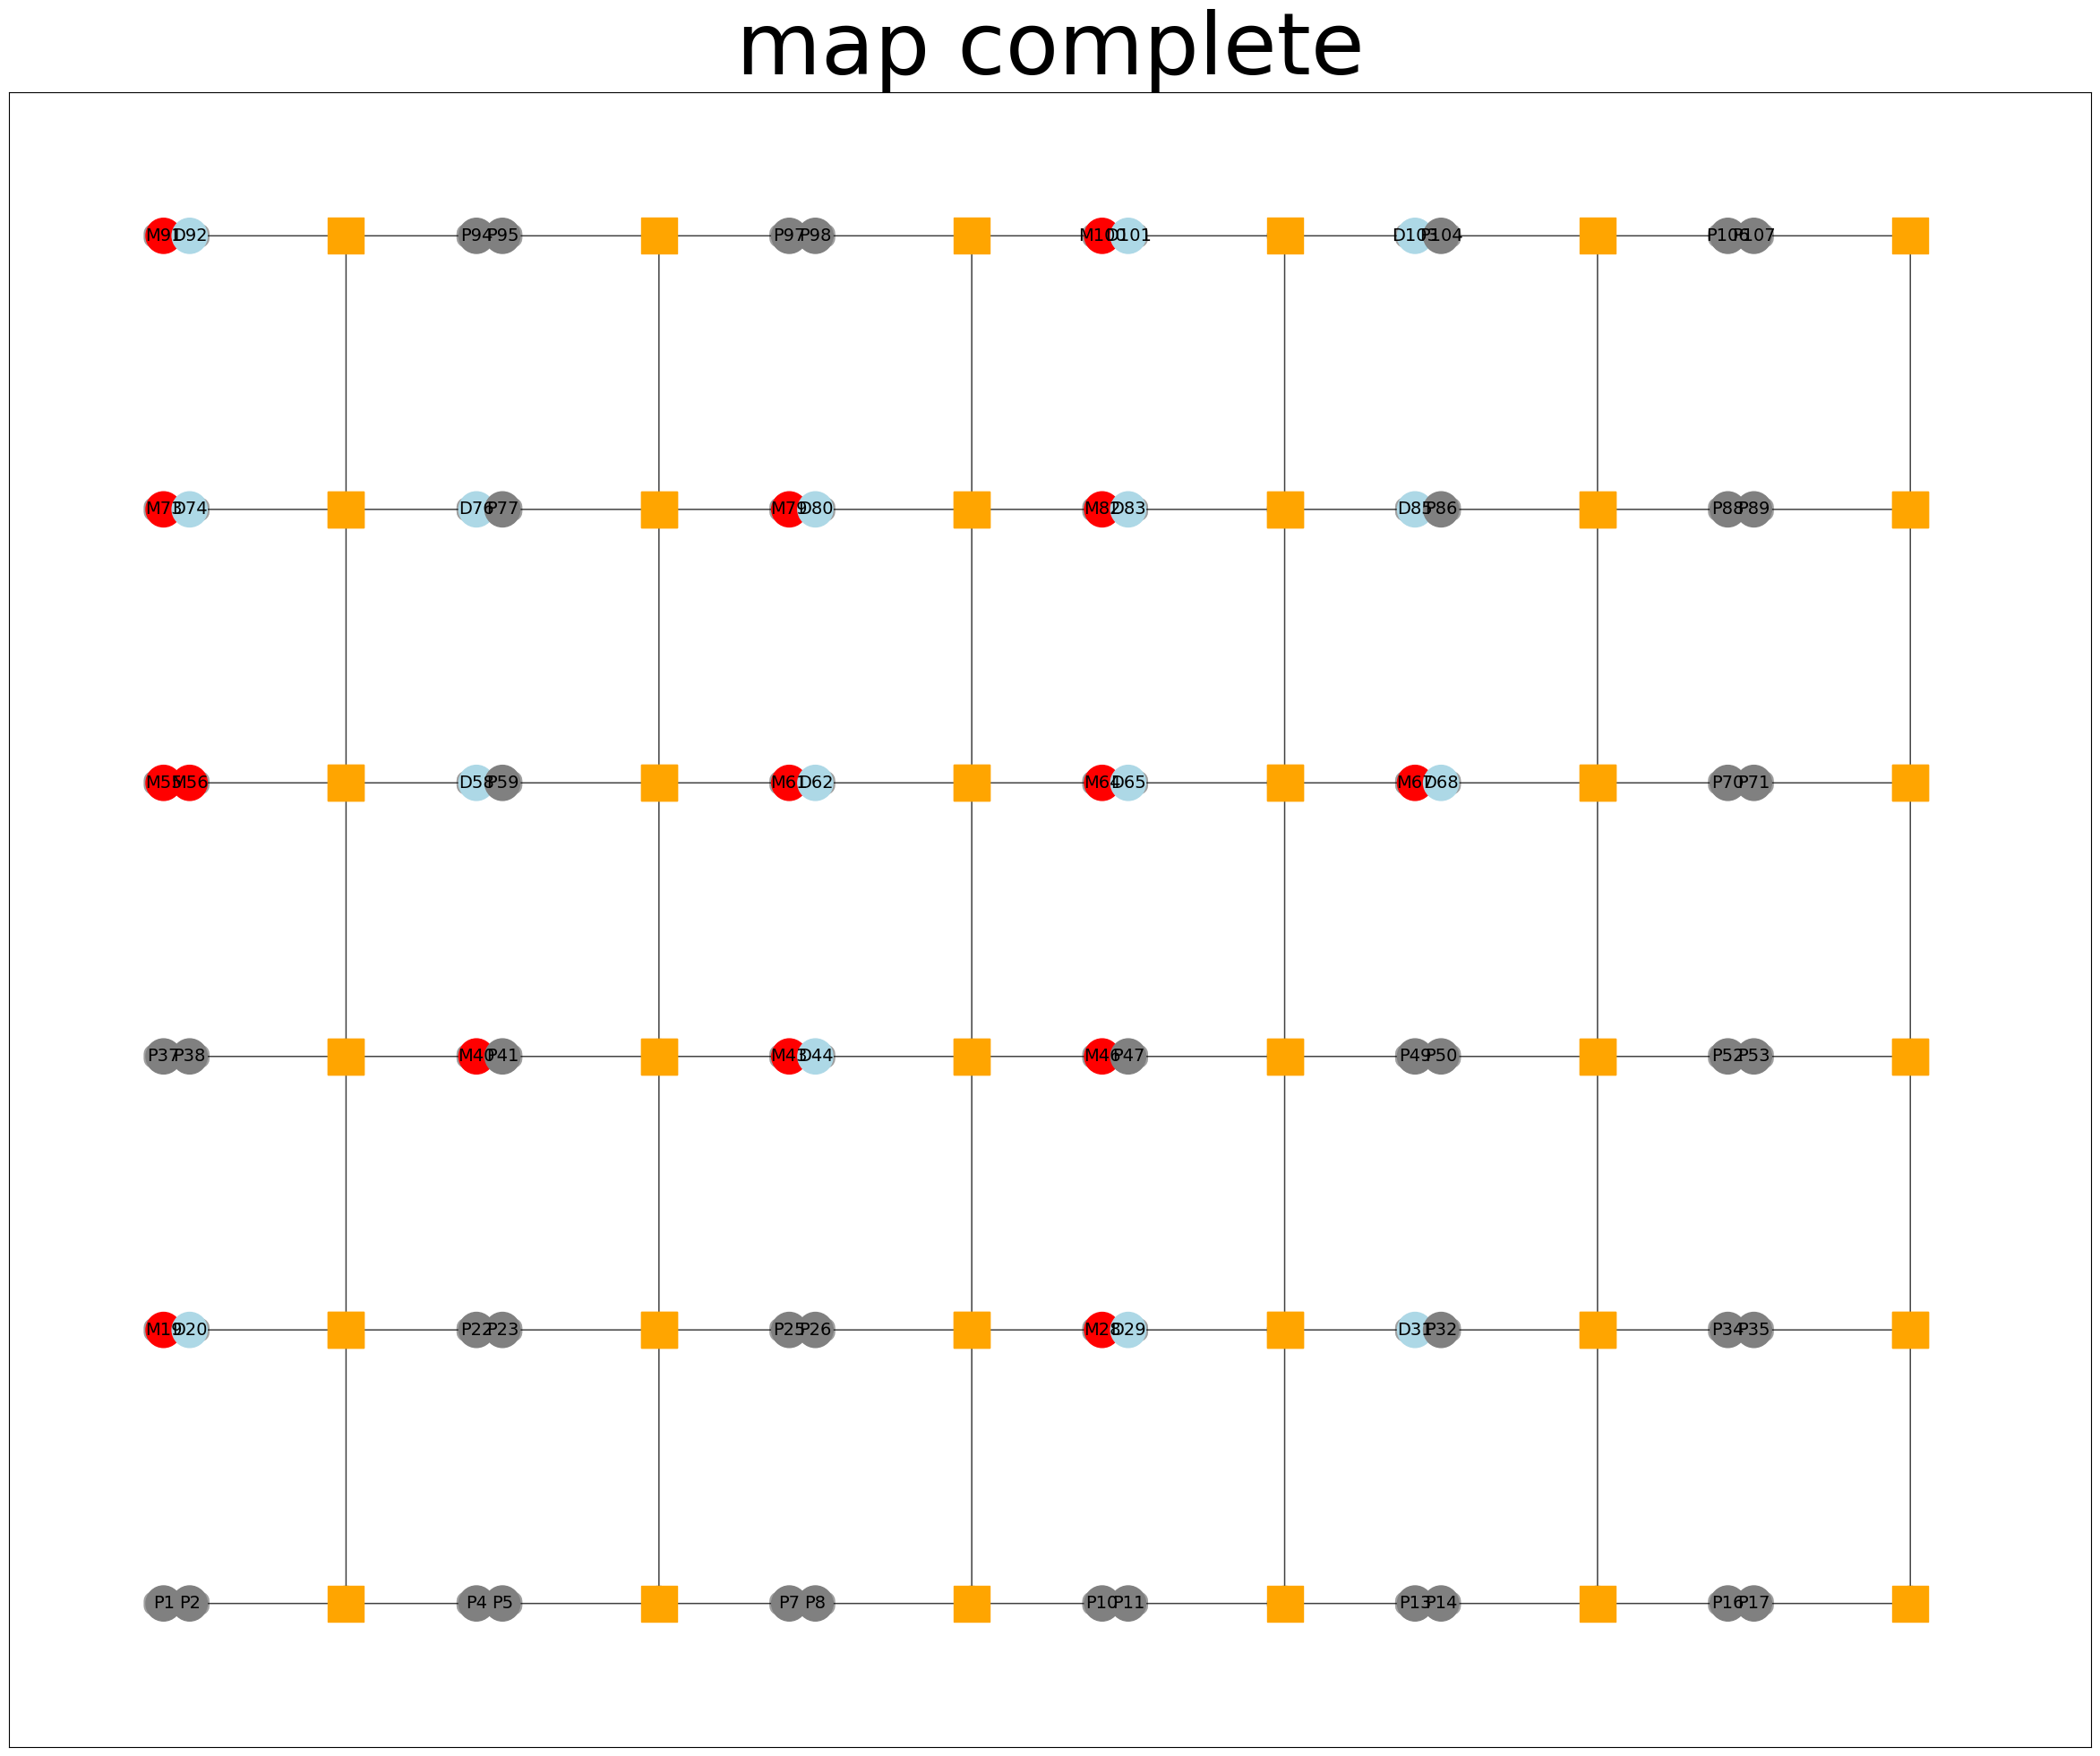

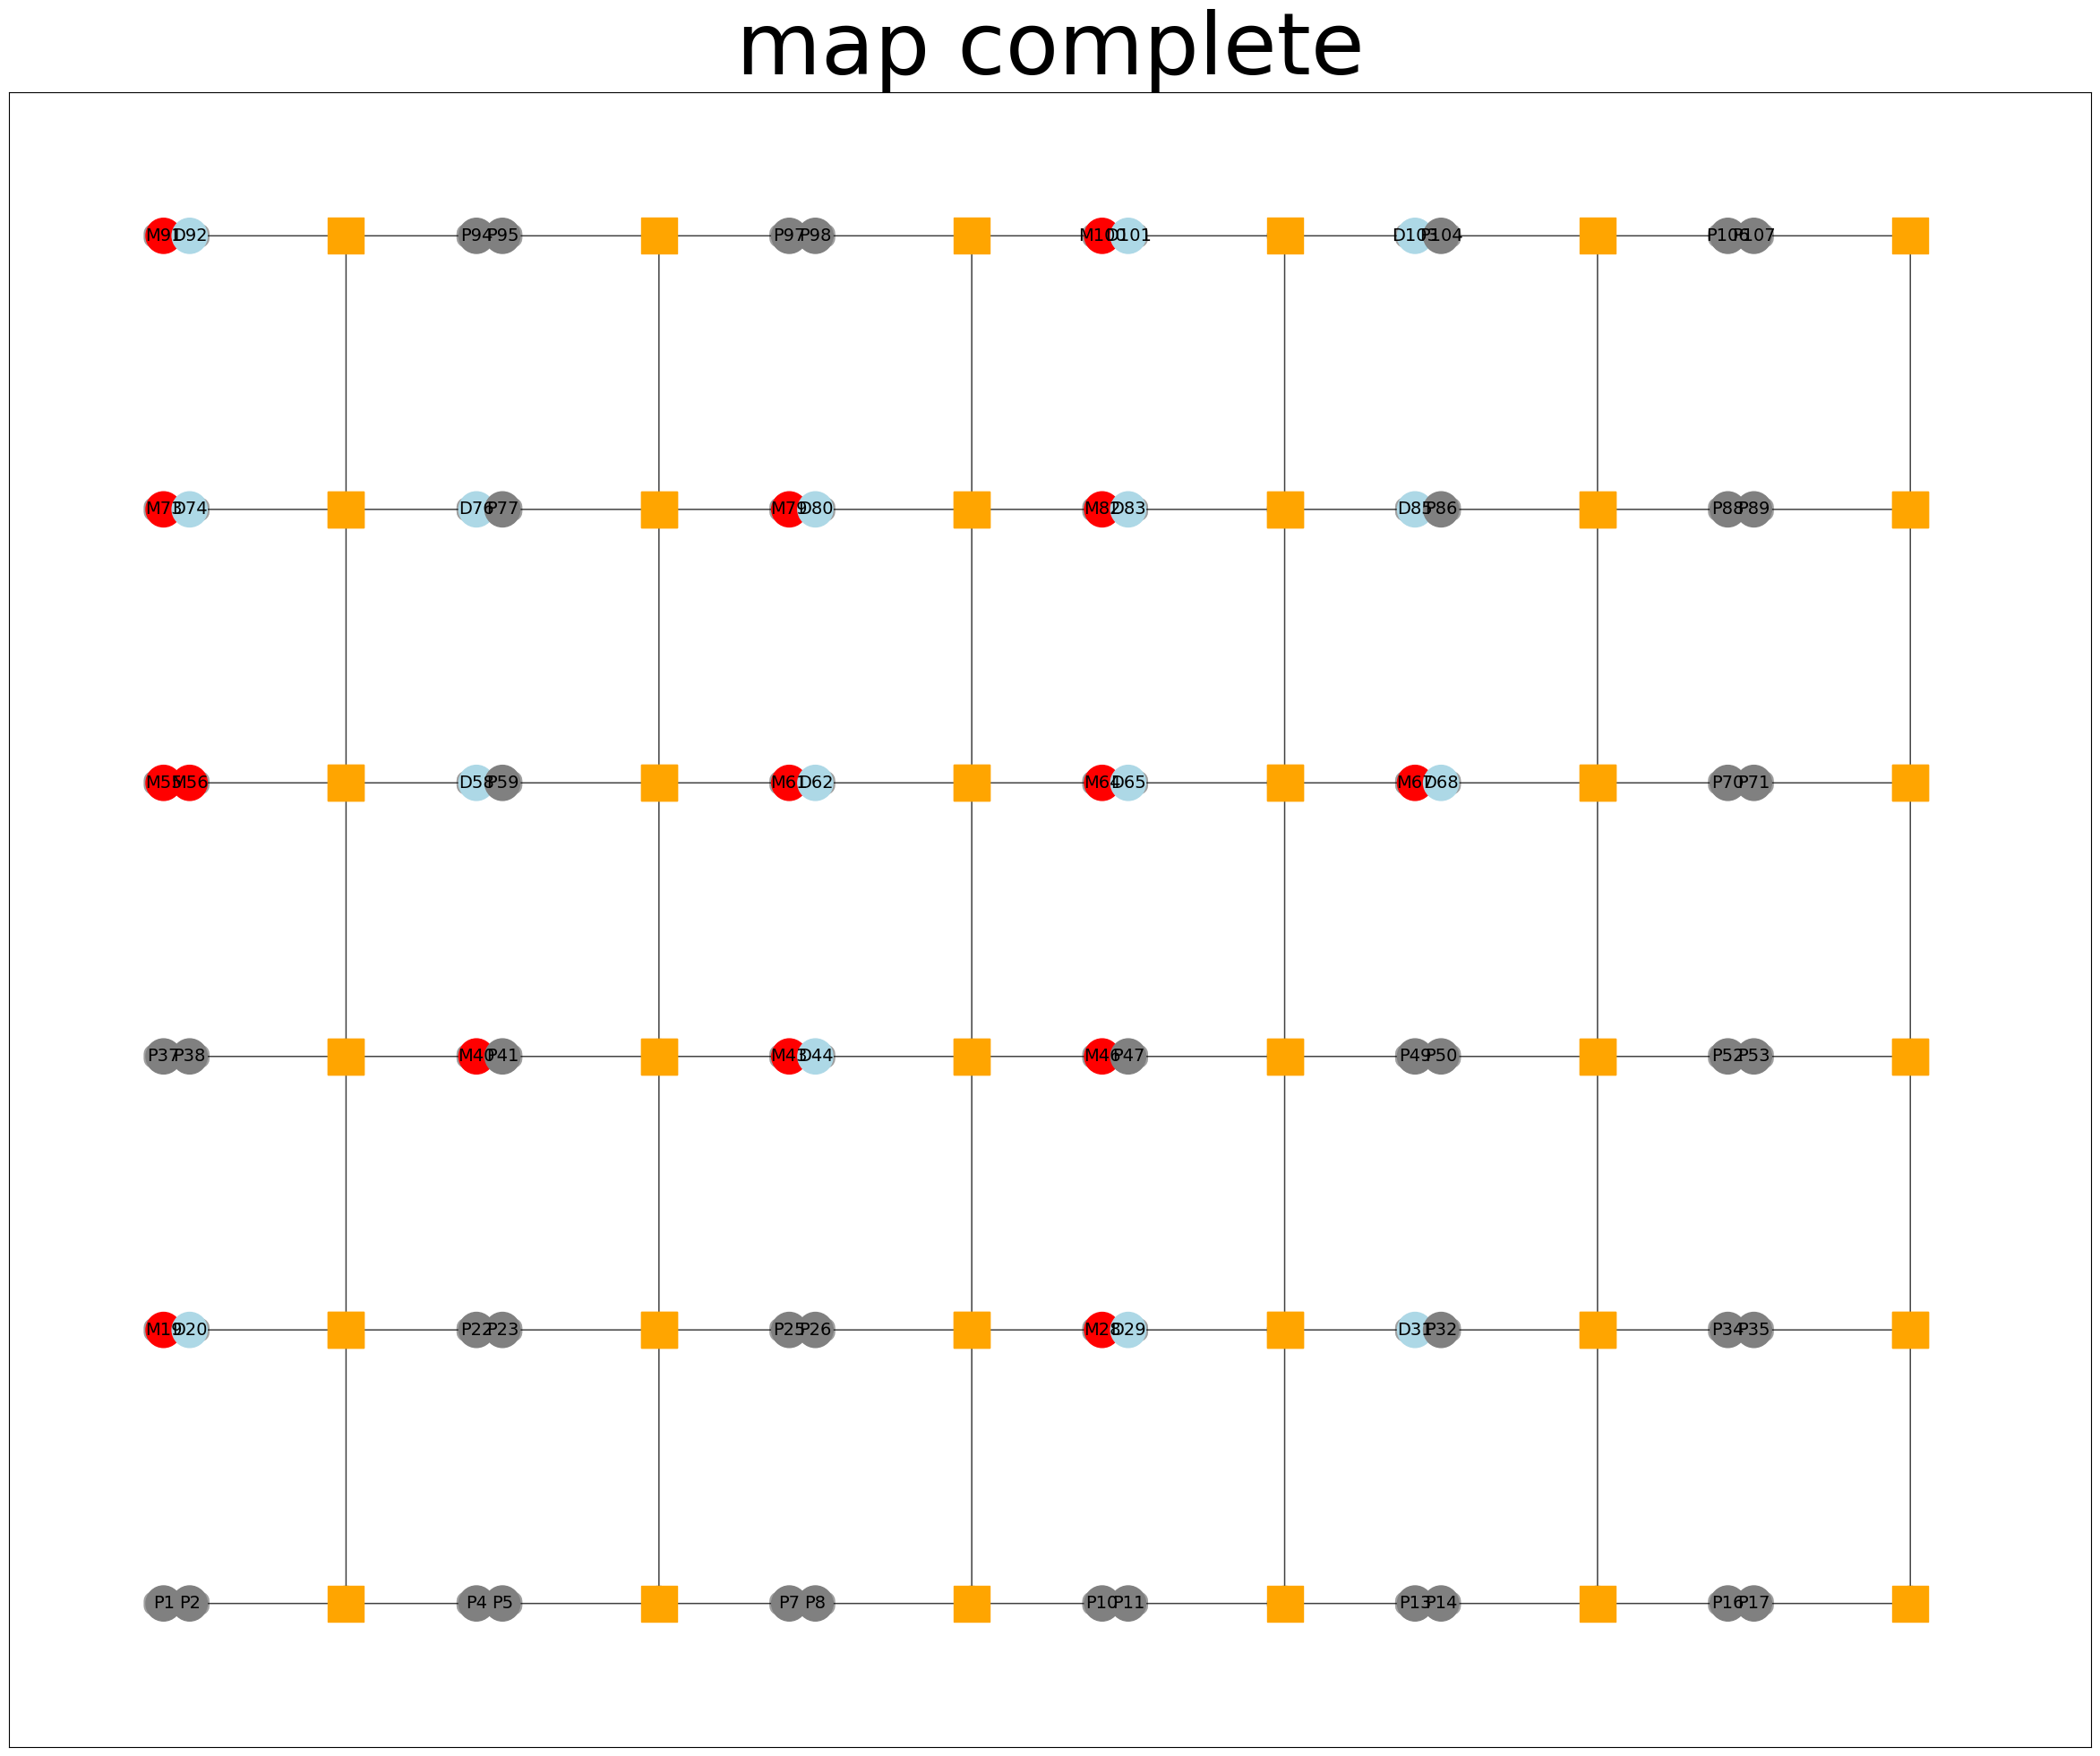

In [1]:
from src.compiler.qccd_ion_routing import *
from src.simulator.qccd_circuit import *
d = 4
subgridsize=(13,7,1)
lookahead=1
# safe to have either barriers or go back
barrierThreshold = np.inf
goBackThreshold = 0
trapCapacity=2

data = {l: 0.0 for l in range(1, 5, 1)}

for lookahead in data.keys():

    circuit = QCCDCircuit.generated(
        "surface_code:rotated_memory_z",
        rounds=1,
        distance=d,
    )
    nqubitsNeeded = 2 * d**2 - 1

    nrowsNeeded = int(np.sqrt(nqubitsNeeded))+2

    # wiseArch = QCCDWiseArch(m=int(np.sqrt(trapCapacity*nqubitsNeeded/2))+1, n=int(np.sqrt(2*nqubitsNeeded/trapCapacity))+1, k=trapCapacity)
    wiseArch =QCCDWiseArch(m=6, n=6, k=trapCapacity)
    arch, (instructions, opBarriers) = circuit.processCircuitWiseArch(wiseArch=wiseArch)
    
    arch.refreshGraph()

    fig,ax =plt.subplots()
    arch.display(fig, ax, title='map complete', showLabels=False)
    # fig.set_size_inches(arch.WINDOW_SIZE[0]*1.5, arch.WINDOW_SIZE[1]*1.5)

    opBarriers = opBarriers if trapCapacity<=barrierThreshold else []
    allOps, barriers = ionRoutingWISEArch(arch, wiseArch, instructions, lookahead=lookahead, subgridsize=subgridsize)
    parallelOpsMap = paralleliseOperationsWithBarriers(allOps, barriers)
    parallelOps = list(dict(parallelOpsMap).values())

    data[lookahead]=max(parallelOpsMap.keys())



[WISE] starting binary search for D in [0, 5]
[WISE] build_structural_cnf(D=2/SAT): D_bound=2, use_wcnf=False, boundary_soft=False, n=4, m=6, R=4
        round 0: |Res_r|=0, |Free_r|=24, |P[r]|=2, |BT[r]|=0
        round 1: |Res_r|=0, |Free_r|=24, |P[r]|=4, |BT[r]|=0
        round 2: |Res_r|=0, |Free_r|=24, |P[r]|=2, |BT[r]|=0
        round 3: |Res_r|=0, |Free_r|=24, |P[r]|=4, |BT[r]|=0
[WISE] SAT worker starting (timeout=60.0s) for CNF: clauses=48216
[WISE] SAT worker finished in 0.033s, SAT=True
[WISE]  test D=2: status=ok, SAT=True, vars=13368, clauses=48216, time=0.584s
[WISE] build_structural_cnf(D=0/SAT): D_bound=0, use_wcnf=False, boundary_soft=False, n=4, m=6, R=4
        round 0: |Res_r|=0, |Free_r|=24, |P[r]|=2, |BT[r]|=0
        round 1: |Res_r|=0, |Free_r|=24, |P[r]|=4, |BT[r]|=0
        round 2: |Res_r|=0, |Free_r|=24, |P[r]|=2, |BT[r]|=0
        round 3: |Res_r|=0, |Free_r|=24, |P[r]|=4, |BT[r]|=0
[WISE] SAT worker starting (timeout=60.0s) for CNF: clauses=60888
[WISE] SA

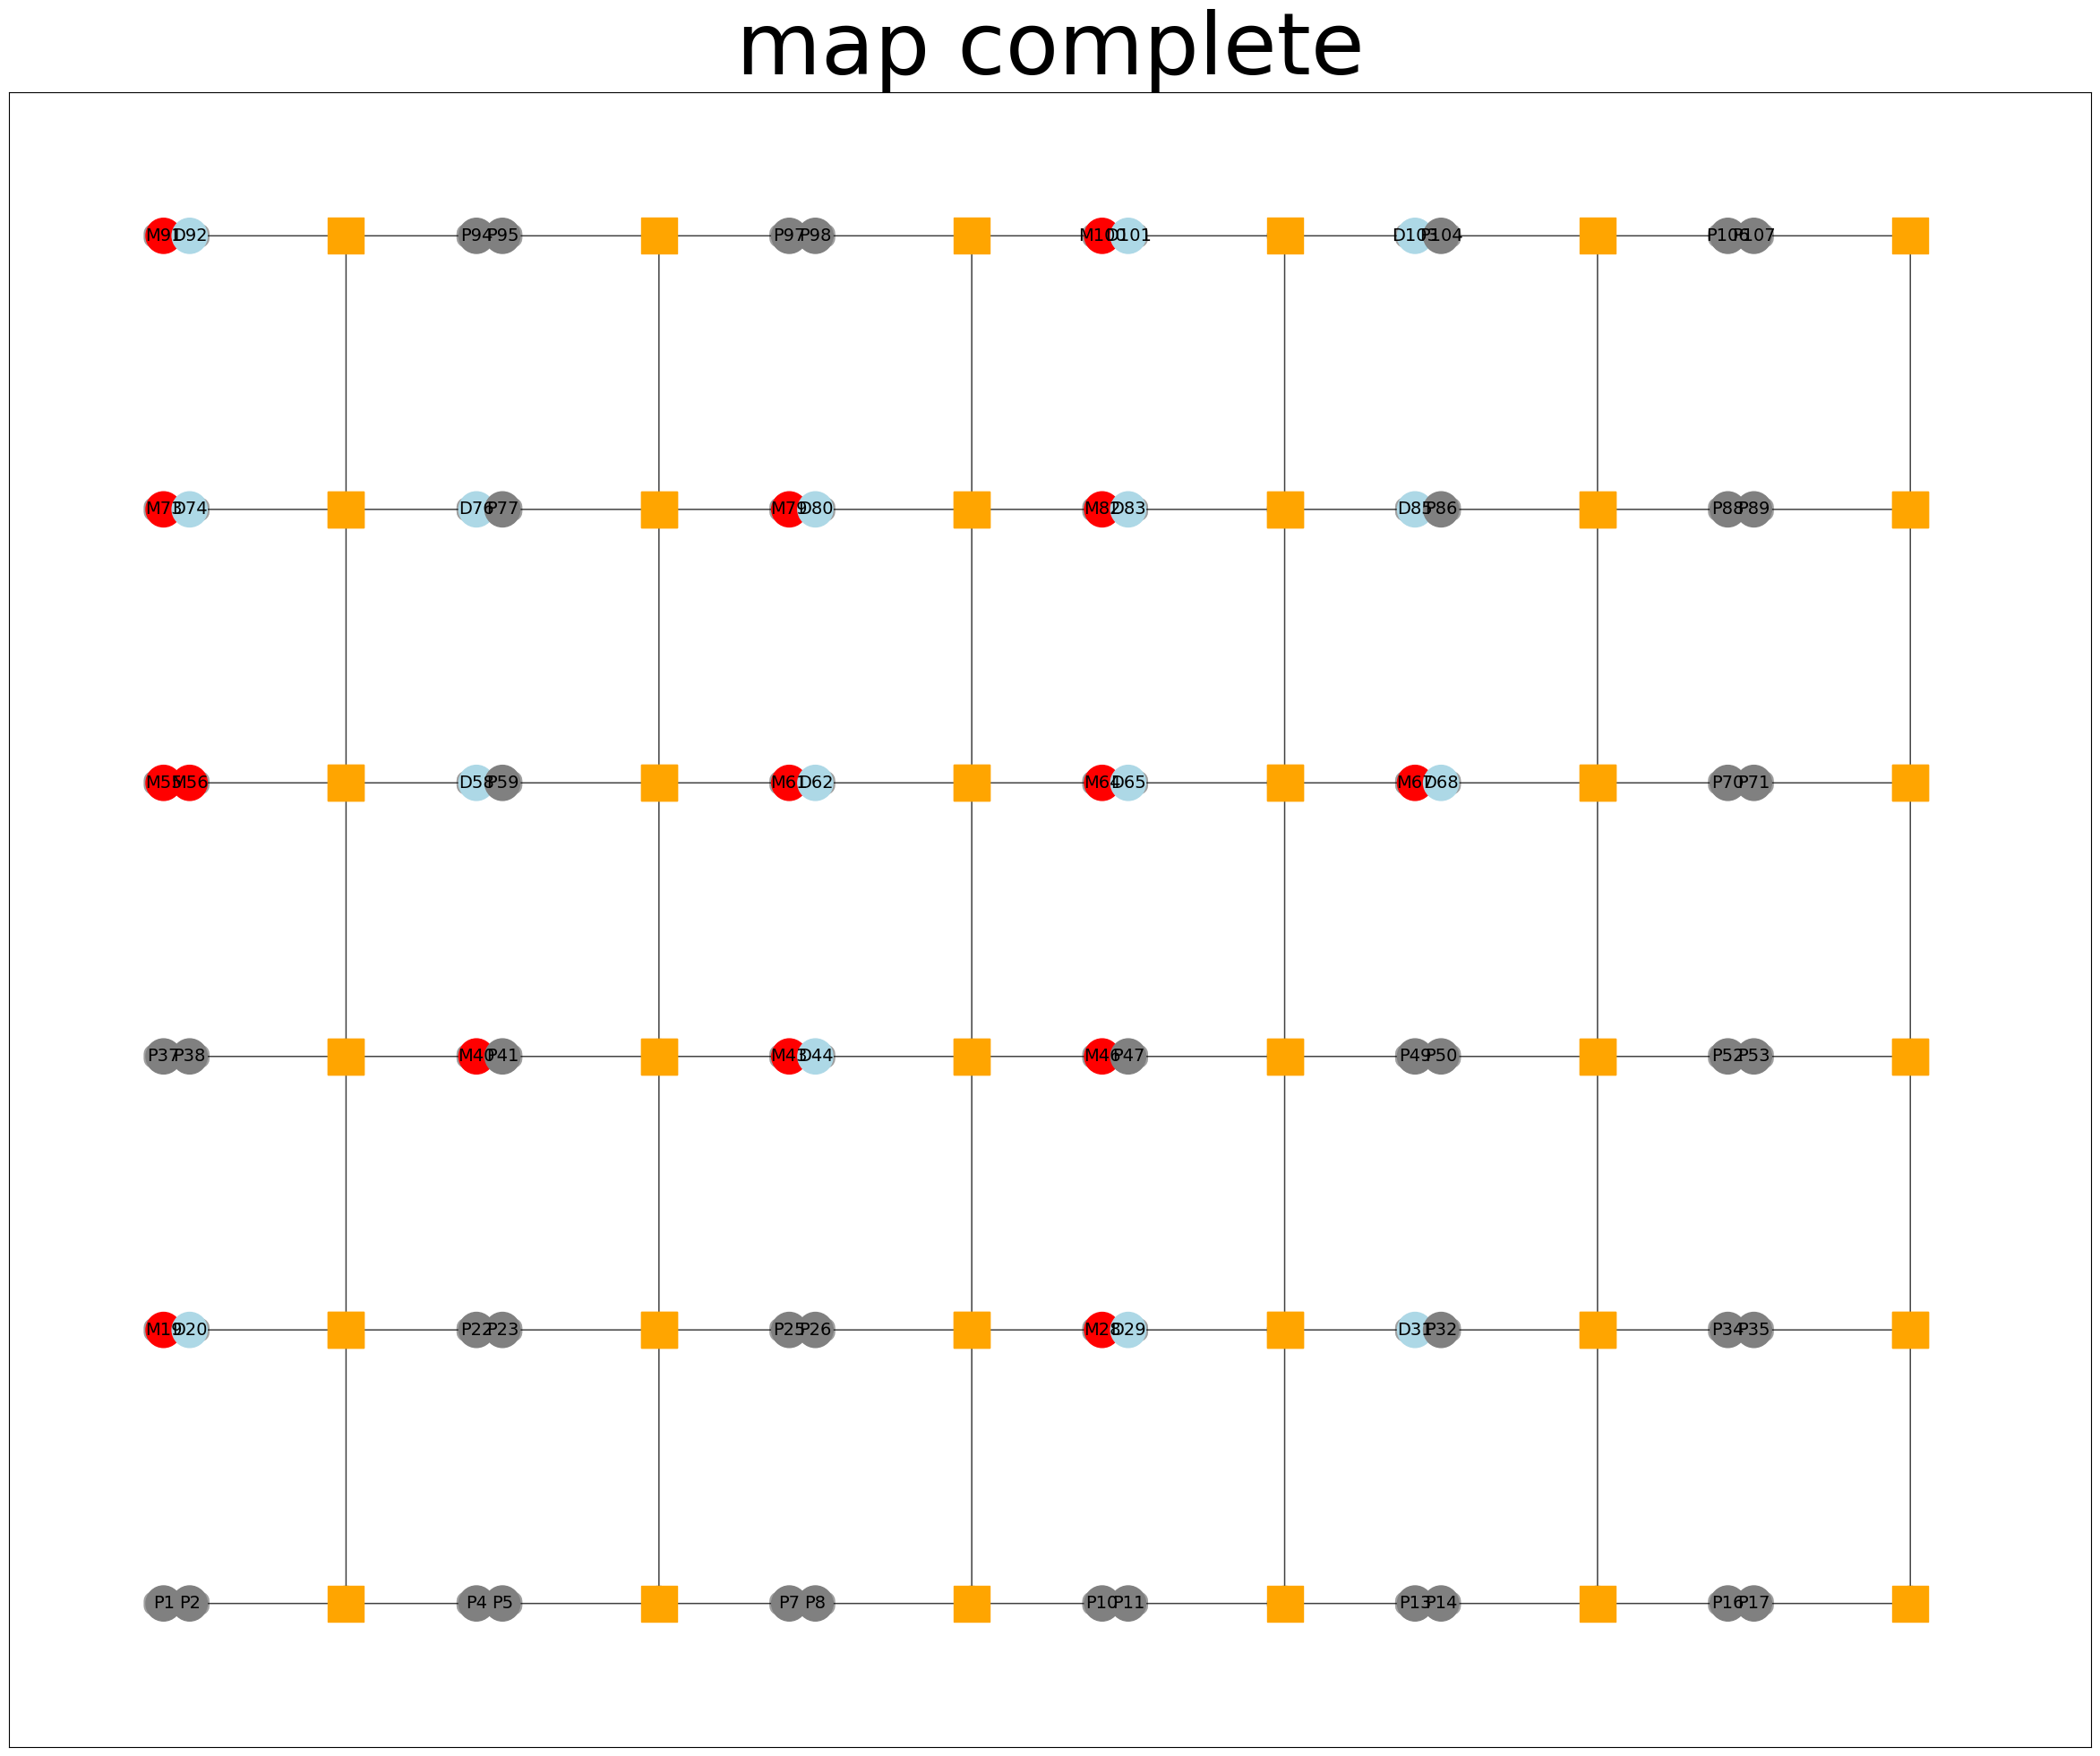

In [20]:
from src.compiler.qccd_ion_routing import *
from src.simulator.qccd_circuit import *
d = 4
subgridsize=(6,4,2)
lookahead=4
# safe to have either barriers or go back
barrierThreshold = np.inf
goBackThreshold = 0
for trapCapacity in [2]:

    circuit = QCCDCircuit.generated(
        "surface_code:rotated_memory_z",
        rounds=1,
        distance=d,
    )
    nqubitsNeeded = 2 * d**2 - 1

    nrowsNeeded = int(np.sqrt(nqubitsNeeded))+2

    # wiseArch = QCCDWiseArch(m=int(np.sqrt(trapCapacity*nqubitsNeeded/2))+1, n=int(np.sqrt(2*nqubitsNeeded/trapCapacity))+1, k=trapCapacity)
    wiseArch =QCCDWiseArch(m=6, n=6, k=trapCapacity)
    arch, (instructions, opBarriers) = circuit.processCircuitWiseArch(wiseArch=wiseArch)
    
    arch.refreshGraph()

    fig,ax =plt.subplots()
    arch.display(fig, ax, title='map complete', showLabels=False)
    # fig.set_size_inches(arch.WINDOW_SIZE[0]*1.5, arch.WINDOW_SIZE[1]*1.5)

    opBarriers = opBarriers if trapCapacity<=barrierThreshold else []
    allOps, barriers = ionRoutingWISEArch(arch, wiseArch, instructions, lookahead=lookahead, subgridsize=subgridsize)
    parallelOpsMap = paralleliseOperationsWithBarriers(allOps, barriers)
    parallelOps = list(dict(parallelOpsMap).values())

    # errs = circuit.simulate(allOps, isWISEArch=True)

    arch = circuit.resetArch()
    arch.refreshGraph()

    # trapSet = set()
    # junctionSet = set()
    # for op in allOps:
    #     for c in op.involvedComponents:
    #         if isinstance(c, Trap):
    #             trapSet.add(c)
    #         elif isinstance(c, Junction):
    #             junctionSet.add(c)


    # Njz = len(junctionSet) # each junction is one zone
    # Nlz = len(trapSet)*trapCapacity # each trap is k zones
    # Nde_lz = 10
    # Nde_jz = 20
    # Nse_z = 10
   

    # Njz = int(np.ceil(nqubitsNeeded / (2*(trapCapacity-1))) )# 2 traps per junction
    # Nlz = nqubitsNeeded-Njz
    # Nde = Nde_lz*Nlz+Nde_jz*Njz
    # Nse = Nse_z*(Njz+Nlz)

    # Num_electrodes = Nde+Nse
    # Num_DACs = Num_electrodes


    # print(f"total number of qubit operations: {len(instructions)}")
    # print(f"total number of operations: {len(allOps)}")
    # print(f"time for operations: {max(parallelOpsMap.keys())}")
    # print(f'Number of Linear Zones: {Nlz}')
    # print(f"Number of Junction Zones: {Njz}")
    # print(f"Number of Electrodes: {Num_electrodes}={Nse}+{Nde}")
    # print(f"Errors: {errs}")


NetworkXNoPath: Target 22 cannot be reached from given sources

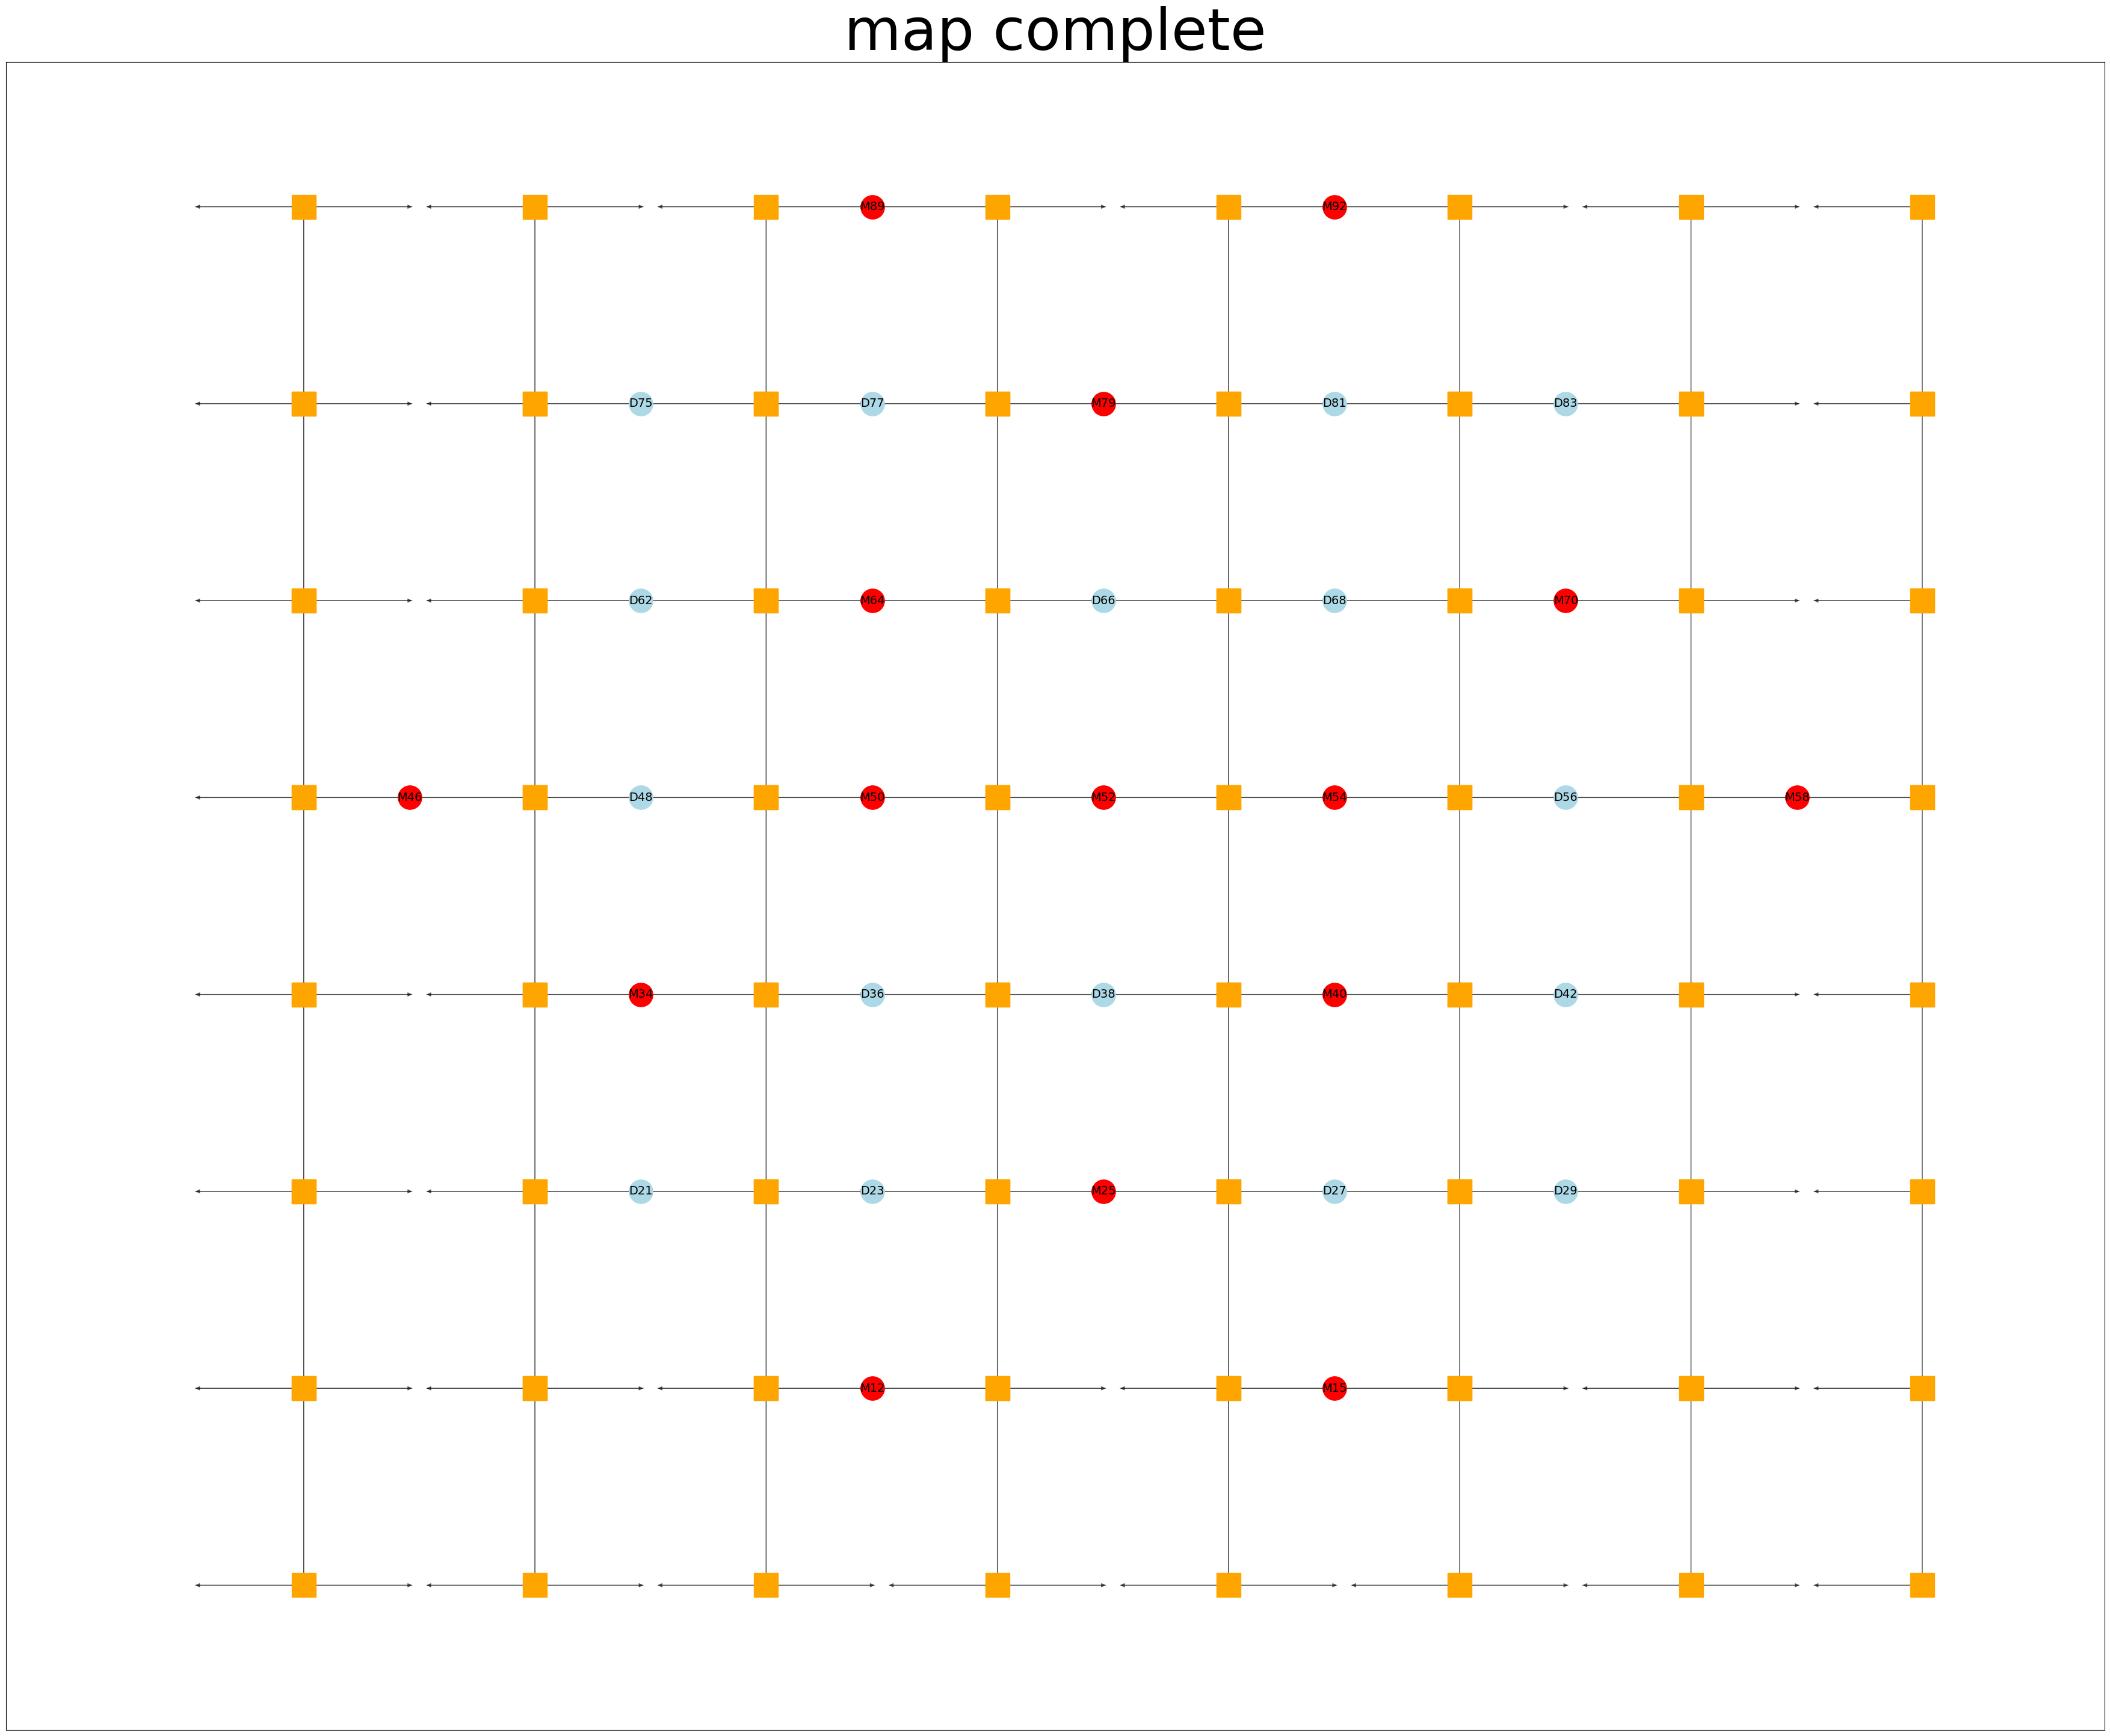

In [6]:
from src.compiler.qccd_ion_routing import *
from src.simulator.qccd_circuit import *
d = 4
# safe to have either barriers or go back
barrierThreshold = np.inf
goBackThreshold = 0
for trapCapacity in [2]:

    circuit = QCCDCircuit.generated(
        "surface_code:rotated_memory_z",
        rounds=1,
        distance=d,
    )
    nqubitsNeeded = 2 * d**2 - 1

    nrowsNeeded = int(np.sqrt(nqubitsNeeded))+2

    wiseArch = QCCDWiseArch(m=int(np.sqrt(trapCapacity*nqubitsNeeded/2))+3, n=int(np.sqrt(2*nqubitsNeeded/trapCapacity))+3, k=trapCapacity)
    arch, (instructions, opBarriers) = circuit.processCircuitWiseArch(wiseArch=wiseArch, addSpectators=False, compactClustering=False)
    
    arch.refreshGraph()

    fig,ax =plt.subplots()
    arch.display(fig, ax, title='map complete', showLabels=False)
    fig.set_size_inches(arch.WINDOW_SIZE[0]*1.5, arch.WINDOW_SIZE[1]*1.5)

    opBarriers = opBarriers if trapCapacity<=barrierThreshold else []
    allOps, barriers = ionRouting(arch, instructions, trapCapacity)
    parallelOpsMap = paralleliseOperationsWithBarriers(allOps, barriers, isWiseArch=True)
    parallelOps = list(dict(parallelOpsMap).values())

    errs = circuit.simulate(allOps, isWISEArch=True)

    arch = circuit.resetArch()
    arch.refreshGraph()

    trapSet = set()
    junctionSet = set()
    for op in allOps:
        for c in op.involvedComponents:
            if isinstance(c, Trap):
                trapSet.add(c)
            elif isinstance(c, Junction):
                junctionSet.add(c)


    Njz = len(junctionSet) # each junction is one zone
    Nlz = len(trapSet)*trapCapacity # each trap is k zones
    Nde_lz = 10
    Nde_jz = 20
    Nse_z = 10
   

    Njz = int(np.ceil(nqubitsNeeded / (2*(trapCapacity-1))) )# 2 traps per junction
    Nlz = nqubitsNeeded-Njz
    Nde = Nde_lz*Nlz+Nde_jz*Njz
    Nse = Nse_z*(Njz+Nlz)

    Num_electrodes = Nde+Nse
    Num_DACs = Num_electrodes


    print(f"total number of qubit operations: {len(instructions)}")
    print(f"total number of operations: {len(allOps)}")
    print(f"time for operations: {max(parallelOpsMap.keys())}")
    print(f'Number of Linear Zones: {Nlz}')
    print(f"Number of Junction Zones: {Njz}")
    print(f"Number of Electrodes: {Num_electrodes}={Nse}+{Nde}")
    print(f"Errors: {errs}")


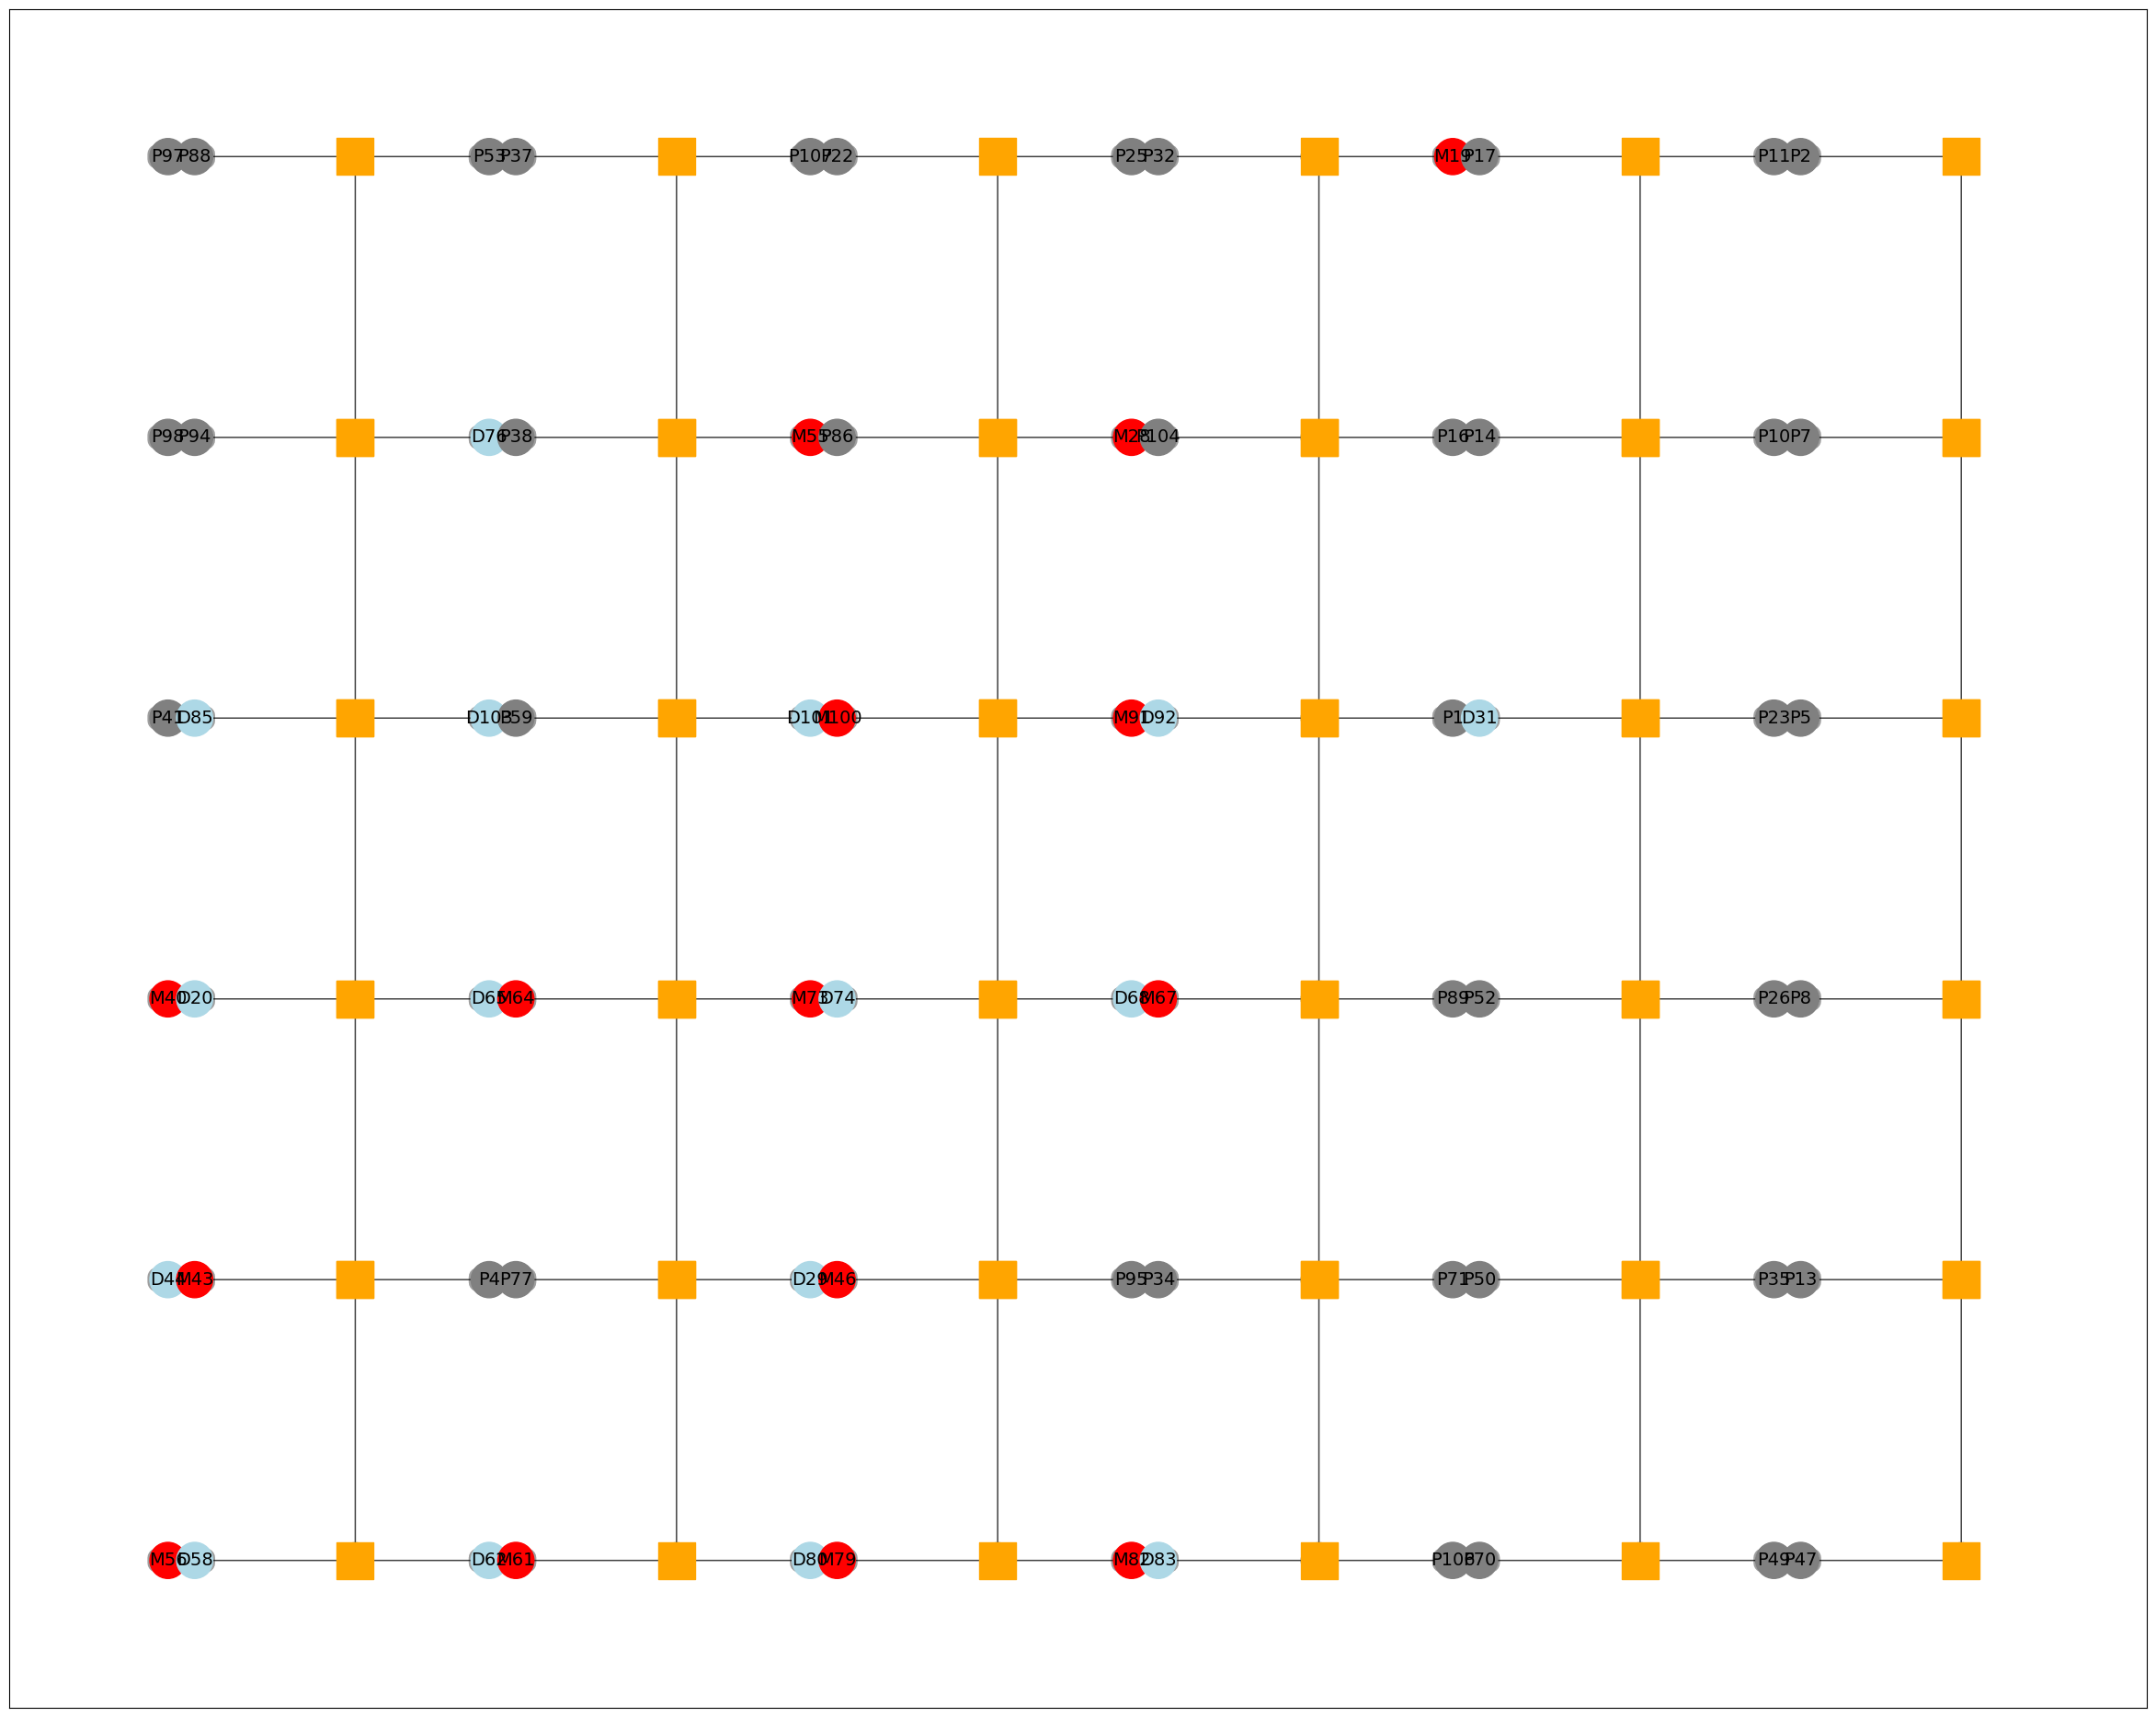

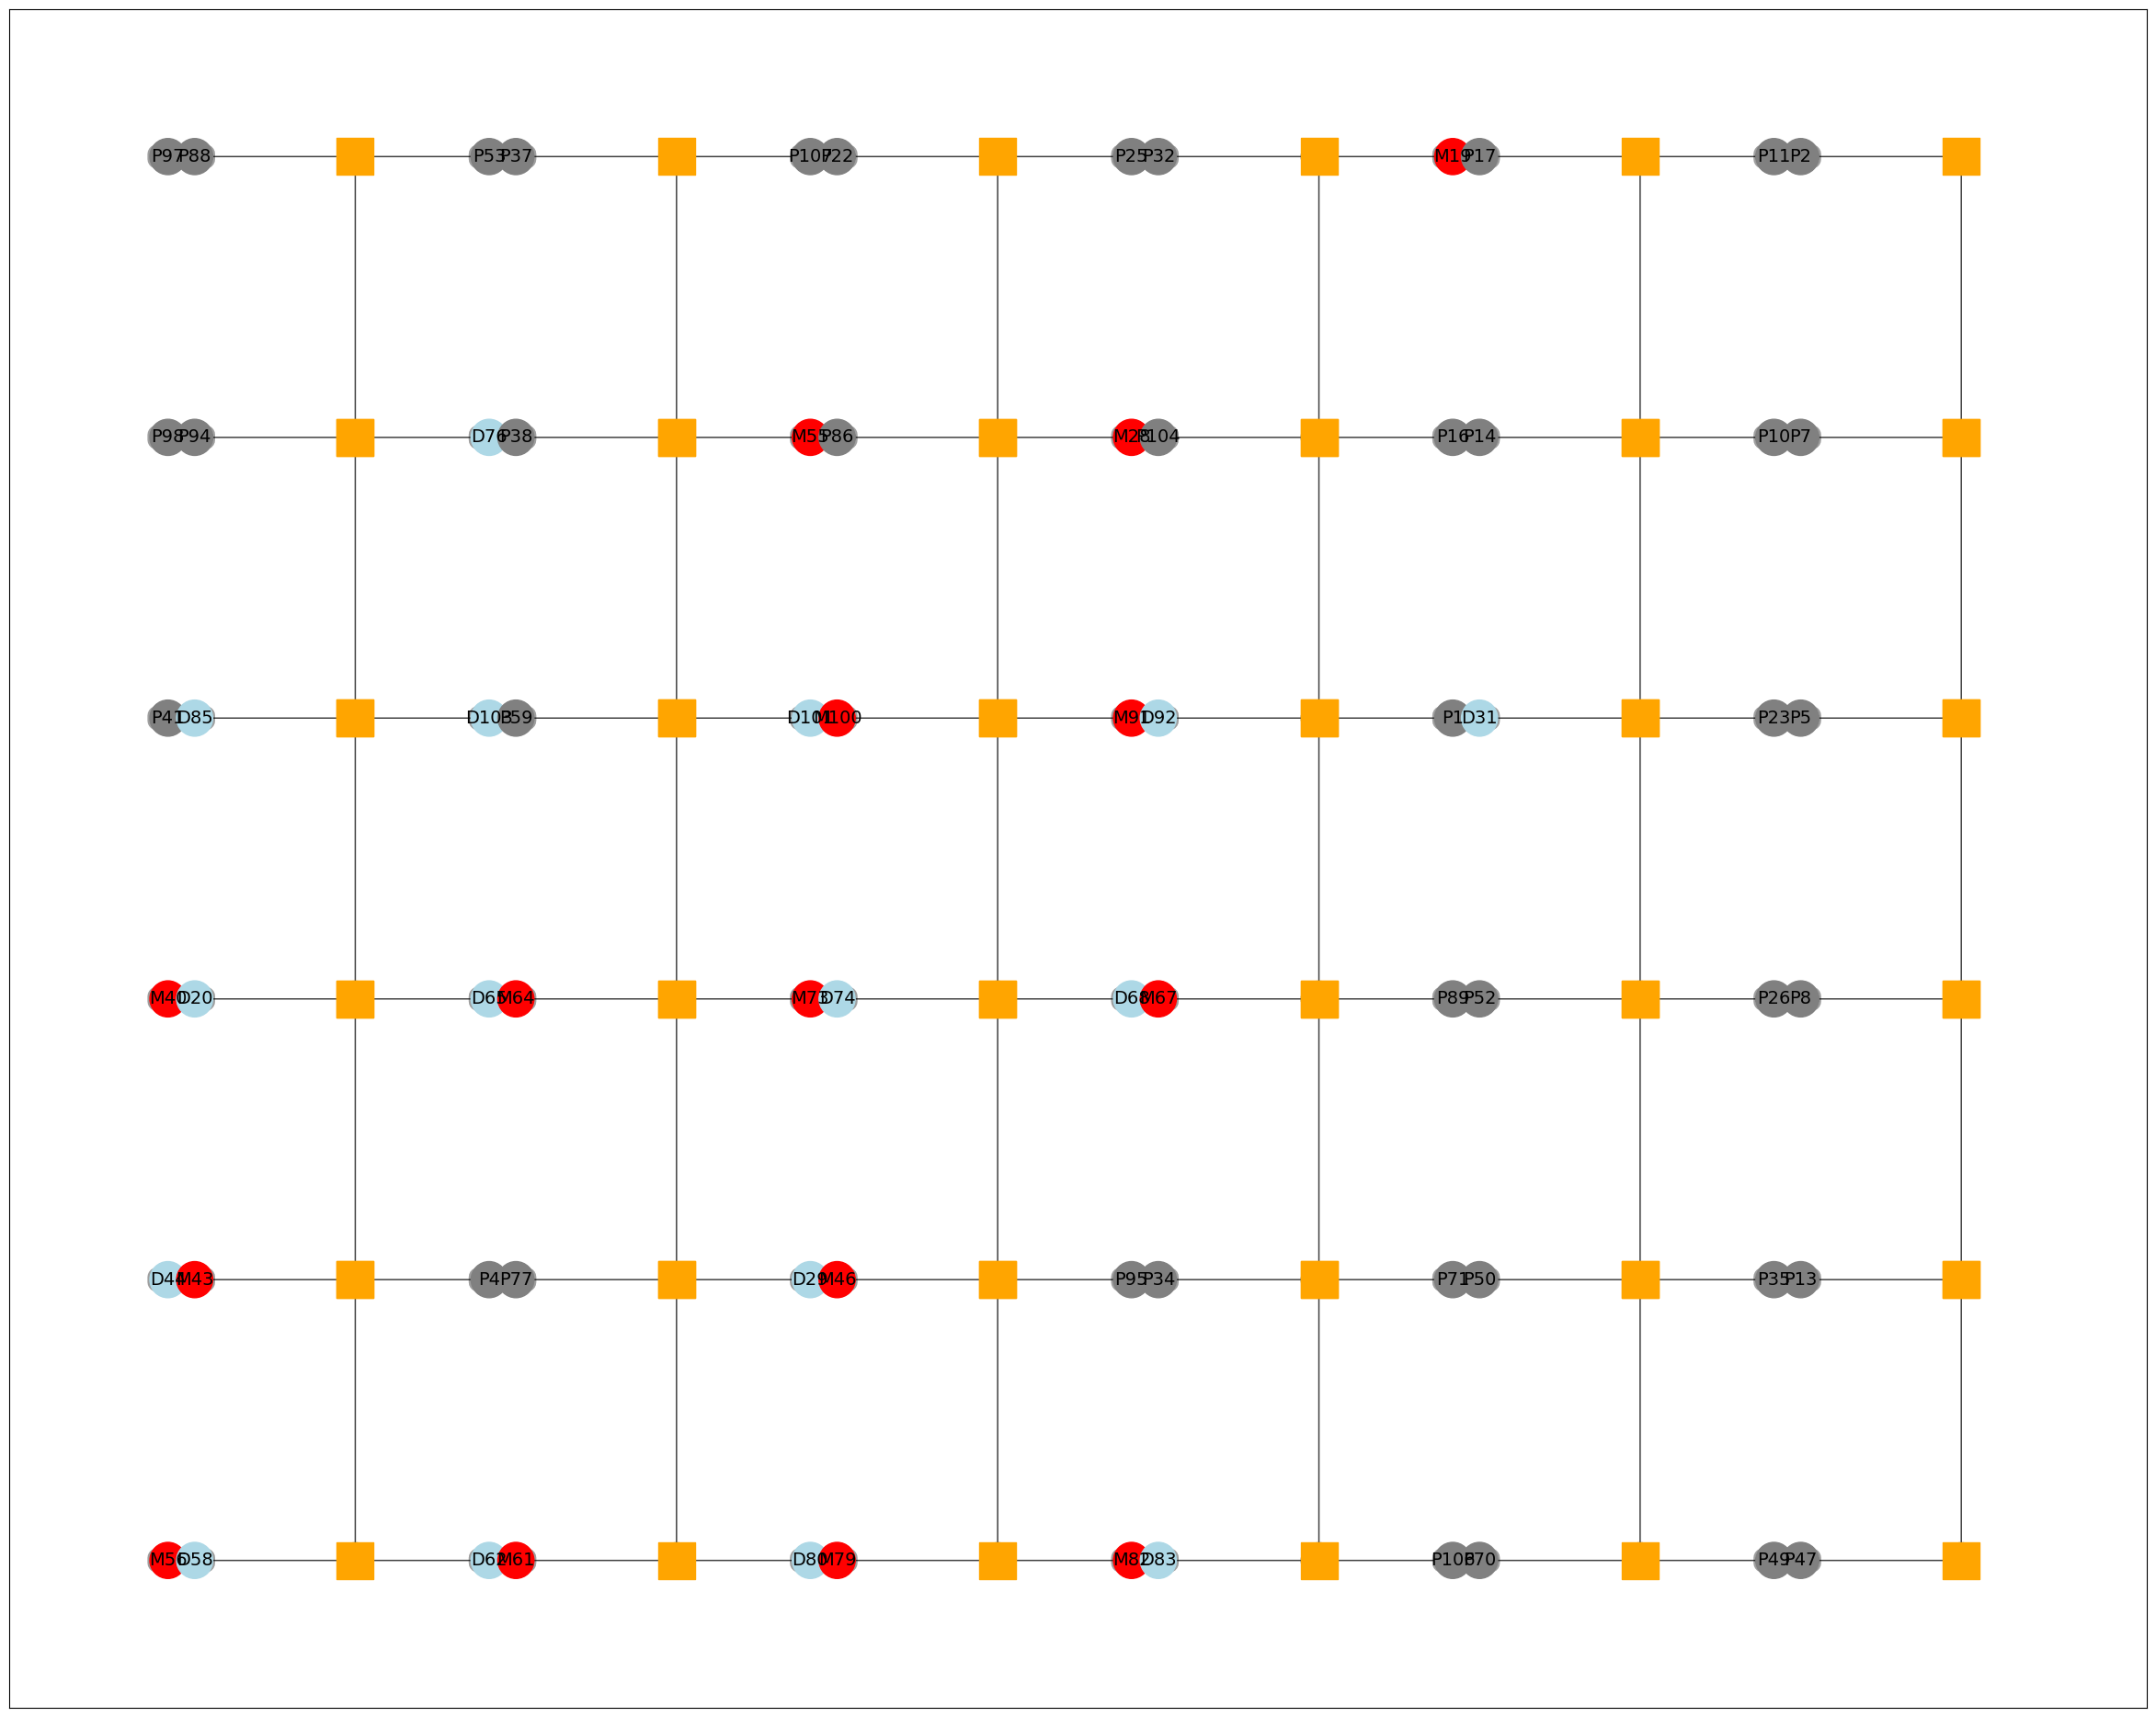

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
%matplotlib inline
from IPython.display import HTML, clear_output, display
import time
arch = circuit.resetArch()
arch.refreshGraph()
fig,ax=plt.subplots()
parallelOpsTimes = sorted(parallelOpsMap.keys())


def update(frame, _arch):
    ax.clear()
    # Clear the output for dynamic display in Jupyter notebook
    clear_output(wait=True)
    if frame>0:
        op: ParallelOperation = parallelOps[frame-1]
        title = f"Operation {round(parallelOpsTimes[frame-1],6)}: {op.label}"
        _arch.display(fig, ax, title, operation=op, runOps=True, showLabels=False)
    else:
        _arch.display(fig, ax, showLabels=False)
    # time.sleep(3)
    return display(fig)
import time
time.sleep(10)
ani = FuncAnimation(fig, lambda frame: update(frame, arch), frames=len(parallelOps)+1, repeat=False)
HTML(ani.to_jshtml())

In [ ]:
!python -m pip install python-sat